#1. Import Dataset

In [1]:
import tensorflow as tf


In [2]:
from google.colab import drive
import numpy as np
import pandas as pd


drive.mount('/content/drive/', force_remount=True)

dir = '/content/drive/My Drive/TA/'
import sys
sys.path.insert(0, dir)


import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings
from CombinedDecays import CombinedDecays
import datetime


Mounted at /content/drive/


In [3]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    for gpu in gpus:
      print(f"Found GPU: {gpu.name}")
  except RuntimeError as e:
    print(e)
else:
  print("No GPU devices found.")

Found GPU: /physical_device:GPU:0


In [4]:
co_df = pd.read_csv("/content/drive/MyDrive/TA/Dataset/co.csv")
co_sea = pd.read_csv("/content/drive/MyDrive/TA/Dataset/Sea/CO_Sea_cleaned.csv")

#2. Class Definition

In [5]:
import tensorflow as tf
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
import warnings

DTYPE='float32'

class MultiSigmaFourierFeatures(tf.keras.layers.Layer):
    def __init__(self, sigmas, mapping_size, trainable_B=False, **kwargs):
        super().__init__(**kwargs)
        self.sigmas = sigmas
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.fourier_layers = [
            FourierFeatureMapping(
                mapping_size=self.mapping_size,
                sigma=sigma,
                trainable_B=self.trainable_B
            ) for sigma in self.sigmas
        ]

    def call(self, inputs):
        outputs = [layer(inputs) for layer in self.fourier_layers]
        return tf.concat(outputs, axis=-1)



class FourierFeatureMapping(tf.keras.layers.Layer):
    def __init__(self, mapping_size=256, sigma=1.0, trainable_B=False, **kwargs):
        super(FourierFeatureMapping, self).__init__(**kwargs)
        self.mapping_size = mapping_size
        self.sigma = sigma
        self.trainable_B = trainable_B

    def build(self, input_shape):
        input_dim = input_shape[-1]
        # Use RandomNormal initializer with stddev = sigma
        self.B = self.add_weight(
            name="B_matrix",
            shape=(input_dim, self.mapping_size),
            initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=self.sigma),
            trainable=self.trainable_B
        )

    def call(self, inputs):
        proj = tf.matmul(inputs, self.B)
        return tf.concat([tf.sin(proj), tf.cos(proj)], axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({
            "mapping_size": self.mapping_size,
            "sigma": self.sigma,
            "trainable_B": self.trainable_B
        })
        return config

# Define model architecture for 2D spatial domain with time
class PINN_NeuralNet(tf.keras.Model):
    def __init__(self, lb, ub,
                 output_dim=1,
                 num_hidden_layers=8,
                 num_neurons_per_layer=20,
                 activation='swish',
                 mapping_size=256,
                 sigma=1.0,
                 sigmas=[1.0, 3.0],
                 kernel_initializer='glorot_normal',
                 trainable_B=True,
                 **kwargs):
        super().__init__(**kwargs)
        self.lb = lb
        self.ub = ub
        self.num_hidden_layers = num_hidden_layers
        self.output_dim = output_dim
        self.mapping_size = mapping_size
        self.trainable_B = trainable_B
        self.sigmas = sigmas
        self.scale = tf.keras.layers.Lambda(lambda x: 2.0*(x - lb)/(ub - lb) - 1.0)
        self.fourier_features = MultiSigmaFourierFeatures(sigmas=self.sigmas, mapping_size=self.mapping_size, trainable_B=True)
        # self.fourier_features = FourierFeatureMapping(mapping_size=mapping_size, sigma=sigma, trainable_B=trainable_B)

        # dummy_input = tf.keras.Input(shape=(3,))
        # _ = self.fourier_features(dummy_input)

        self.hidden = [tf.keras.layers.Dense(num_neurons_per_layer,
                                             activation=tf.keras.activations.get(activation),
                                             kernel_initializer=kernel_initializer)
                       for _ in range(self.num_hidden_layers)]
        self.out = tf.keras.layers.Dense(output_dim)


    def call(self, X):
        """Forward-pass through neural network."""
        X = tf.convert_to_tensor(X, dtype=tf.float32)  # Ensure X is a Tensor
        X = tf.reshape(X, (-1, 3))  # Ensure input is 2D (batch_size, features) for [t, x, y]
        Z = self.scale(X)
        Z = self.fourier_features(Z)
        for i in range(self.num_hidden_layers):
            Z = self.hidden[i](Z)
        return self.out(Z)


class PINN_PDESolver():
    def __init__(self, model, X_r, fun_r, get_r,lambd=1):
        self.model = model

        # Store collocation points
        # X_r = tf.convert_to_tensor(X_r, dtype=tf.float32)  # Ensure X_r is a Tensor
        self.t = X_r[:,0:1]
        self.x = X_r[:,1:2]
        self.y = X_r[:,2:3]
        self.lambd = lambd
        # Initialize history of losses and global iteration counter
        self.hist = []
        self.lambd_list = []  # Initialize lambda list here
        self.iter = 0
        self.fun_r = fun_r
        self.get_r_fn = get_r

    def get_r(self):
        return self.get_r_fn(t=self.t, x=self.x, y=self.y, model=self.model, lambd = self.lambd, fun_r=self.fun_r)

    def loss_fn(self, X, u):
        # X = tf.convert_to_tensor(X, dtype=tf.float32)
        # X = tf.reshape(X, (-1, 3))  # Ensure input is 3D [t, x, y]
        # u = tf.convert_to_tensor(u, dtype=tf.float32)

        # Compute phi_r
        r = self.get_r()
        phi_r = r

        # Initialize loss
        loss = phi_r

        return loss, phi_r
    @tf.function
    def get_grad(self, X, u):
        X = tf.convert_to_tensor(X, dtype=tf.float32)
        u = tf.convert_to_tensor(u, dtype=tf.float32)

        with tf.GradientTape() as tape:
            loss, phi_r = self.loss_fn(X, u)
        grad_theta = tape.gradient(loss, self.model.trainable_variables)

        return loss, grad_theta

    def solve_with_TFoptimizer(self, optimizer, X, u, inverse=True, N=None, min_loss=None, timeout=None):
        X = tf.convert_to_tensor(X, dtype=tf.float32)  # Ensure X is Tensor
        u = tf.convert_to_tensor(u, dtype=tf.float32)  # Ensure u is Tensor

        @tf.function
        def train_step():
          loss, grads = self.get_grad(X, u)
          optimizer.apply_gradients(zip(grads, self.model.trainable_variables))
          return loss

        def loss_callback():
            loss = train_step()
            self.current_loss = loss.numpy()

            print(f"Iteration {self.iter}, Loss: {self.current_loss}")
            self.hist.append(self.current_loss)
            self.iter += 1

        start_time = time.time()
        if timeout is not None:
            while time.time() - start_time < timeout:
                loss_callback()
        elif N is not None:
            for _ in range(N):
                loss_callback()
        elif min_loss is not None:
            while self.current_loss > min_loss:
                loss_callback()

    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print('It {:05d}: l_u = {:10.8e} loss = {:10.8e}'.format(self.iter,self.phi_0_b,self.current_loss))
        self.hist.append(self.current_loss)
        self.iter+=1

    def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
        upred = self.model(tf.cast(test_data, DTYPE))  # shape: [N, 1]

        # Reshape into [Nt+1, Nx+1, Ny+1]
        Nt, Nx, Ny = len(t_unique) - 1, len(x_unique) - 1, len(y_unique) - 1
        U = upred.numpy().reshape(Nt+1, Nx+1, Ny+1)

        # Create meshgrid for visualization
        T, X, Y = np.meshgrid(t_unique, x_unique, y_unique, indexing='ij')
        self.T_pred, self.X_pred, self.Y_pred = T, X, Y

        return U

    def plot_solution_at_time(self, U=None, time_idx=0, **kwargs):
        # If upred has not been predicted
        if U is None:
            U = self.predict_solution()

        # Plot solution at specific time
        fig = plt.figure(figsize=(9,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(self.X_pred[time_idx], self.Y_pred[time_idx], U[time_idx], cmap='viridis', **kwargs)
        ax.set_xlabel('$x$')
        ax.set_ylabel('$y$')
        ax.set_zlabel('$u_\\theta(t,x,y)$')
        ax.set_title(f'Solution at t = {self.T_pred[time_idx,0,0]:.2f}')
        return ax

    def plot_loss_history(self, ax=None):
        if not ax:
            fig = plt.figure(figsize=(7,5))
            ax = fig.add_subplot(111)
        ax.semilogy(range(len(self.hist)), self.hist,'k-')
        ax.set_xlabel('$n_{epoch}$')
        ax.set_ylabel('$\\phi^{n_{epoch}}$')
        return ax



def predict_solution(self, test_data,t_unique,x_unique,y_unique):
        # Predict using the scaled input
    upred = self(tf.cast(test_data, DTYPE))  # shape: [N, 1]

    #     # Reshape into [Nt+1, Nx+1, Ny+1]
    # Nt, Nx, Ny = len(t_unique) - 1, len(x_unique) - 1, len(y_unique) - 1
    # U = upred.numpy().reshape(Nt+1, Nx+1, Ny+1)

    #     # Create meshgrid for visualization
    # T, X, Y = np.meshgrid(t_unique, x_unique, y_unique, indexing='ij')
    # self.T_pred, self.X_pred, self.Y_pred = T, X, Y

    return upred

def calculate_mae(u_pred, u_true):
    """Calculate Mean Absolute Error"""
    return np.mean(np.abs(u_true - u_pred))

def calculate_mape(u_pred, u_true, epsilon=1e-10):
    """Calculate Mean Absolute Percentage Error"""
    return 100 * np.mean(np.abs((u_true - u_pred) / (np.abs(u_true) + epsilon)))

def evaluate_solution(u_pred, u_true):
    """Evaluate solution using MAE and MAPE"""
    mae = calculate_mae(u_pred, u_true)
    mape = calculate_mape(u_pred, u_true)
    # r2 =   calculate_rel_l2(u_pred, u_true)

    return mae, mape

def calculate_rel_l2(u_pred, u_true, epsilon=1e-10):
    """Relative L2 norm error"""
    return np.linalg.norm(u_pred - u_true) / (np.linalg.norm(u_true) + epsilon)


def evaluate_param(lambda_pred, lambda_true):
    """Evaluate parameter using absolute error and percentage error"""
    abs_error = np.abs(lambda_true - lambda_pred)
    perc_error = 100 * abs_error / np.abs(lambda_true)
    return abs_error, perc_error

def plot_solution_slice(U, T, X, Y, time_idx=0):
    """Plot solution slice at specific time index"""
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X[time_idx], Y[time_idx], U[time_idx],
                          cmap='viridis', edgecolor='none')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('u(t,x,y)')
    ax.set_title(f'Solution at t = {T[time_idx,0,0]:.2f}')
    fig.colorbar(surf, shrink=0.5, aspect=5)
    plt.show()


class Hybrid_IdentificationNet(PINN_NeuralNet):
    def __init__(self, initial_lambda, *args, **kwargs):
        # Call init of base class
        super().__init__(*args,**kwargs)
        self.initial_lambda = initial_lambda

        if isinstance(initial_lambda, (list, np.ndarray)):
            self.initial_lambda = np.array(initial_lambda, dtype=DTYPE)
        else:
            self.initial_lambda = initial_lambda

        # Initialize variable for lambda
        self.lambd = tf.Variable(initial_value=self.initial_lambda, trainable=True, dtype=DTYPE, constraint=lambda x: tf.clip_by_value(x, 1e-5, 10.0))
        self.lambd_list = []

    def build(self, input_shape):
           super().build(input_shape)  # Ensure layers are initialized
           self.built = True


    def add_param(self):
        try:
          len(self.initial_lambda)
          self.initial_lambda = np.array(self.initial_lambda, dtype=DTYPE)
        except TypeError as e:
          pass

    @property
    def trainable_variables(self):
        # Combine neural network weights with lambda parameter
        return super().trainable_variables + [self.lambd]

class Hybrid_IdentificationSolver(PINN_PDESolver):
    def solve_with_TFoptimizer(self, optim_fwd, optim_param, get_r_param, X, u,
                               N_fwd=None, min_loss_fwd=None, timeout_fwd=None,
                               N_param=None, min_loss_param=None, timeout_param=None, modified=False, **kwargs):
        self.changed = False
        self.lambd_list = []
        super().solve_with_TFoptimizer(optim_fwd, X, u, N=N_fwd, min_loss=min_loss_fwd, timeout=timeout_fwd, **kwargs)

        # Add parameters after fitting
        # with given data.
        self.model.add_param()
        self.changed = True

        print('\n\nFinding PDE parameters.')

        if modified is True:

            @tf.function
            def train_step_param():
                loss, grad_theta = get_r_param()

                # Perform gradient descent step, update the weights of the model.
                optim_param.apply_gradients(zip([grad_theta], [self.model.lambd]))
                return loss

            def loss_callback():
                loss = train_step_param()

                self.current_loss = loss.numpy()
                callback()

        else:
            @tf.function
            def train_step_param_unmodified():
                 with tf.GradientTape() as tape:
                    tape.watch(self.model.lambd)
                    # phi_r is calculated only after
                    # variables are added.
                    # Compute phi_r
                    r = self.get_r()
                    loss = r

                 grad_lambd = tape.gradient(loss, self.model.lambd)
                 optim_param.apply_gradients(zip([grad_lambd], [self.model.lambd]))
                 return loss


            def loss_callback():
                loss = train_step_param_unmodified()
                self.current_loss = loss.numpy()
                callback()



        def callback():
                lambd = self.model.lambd.numpy()
                self.model.lambd_list.append(lambd)

                if self.iter % 10 == 0:
                    print('It {:05d}: loss = {:10.8e} lambda = '.format(self.iter, self.current_loss) + str(lambd))

                self.hist.append(self.current_loss)
                self.iter += 1

        if N_param is not None:
            for _ in range(N_param):
                loss_callback()

            print ('{} iterations reached.'.format(N_param))

        elif min_loss_param is not None:
            while True:
                loss_callback()

                if self.current_loss < min_loss_param:
                    print ('Loss is reached. Current loss: {:10.8e}'.format(self.current_loss))
                    break

        elif timeout_param is not None:
            t0 = time.time()
            stop_after = time.time() + timeout_param

            while True:
                loss_callback()

                if time.time() > stop_after:
                    print ('Timeout is reached. Time elapsed: {} seconds'.format(time.time()-t0))
                    break

    def loss_fn(self, X, u):
        # Initialize loss
        loss = 0
        phi_r = 0

        # phi_r is calculated only after
        # variables are added.
        if self.changed is not False:
            # Compute phi_r
            r = self.get_r()
            phi_r =r
            loss += phi_r

        else:
            u_pred = self.model(X)
            loss += tf.reduce_mean(tf.square(u - u_pred))

        return loss, phi_r

    def callback(self, xr=None):
        if self.iter % 50 == 0:
            print('It {:05d}: l_u = {:10.8e} loss = {:10.8e}'.format(self.iter,self.phi_0_b,self.current_loss))
            # print('It {:05d}: loss = {:10.8e}'.format(self.iter,self.current_loss))
        self.hist.append(self.current_loss)
        self.iter+=1

# 3. Data PreProcessing and Training-Testing Split

In [6]:
co_df

,Unnamed: 0,x_coord,y_coord,date,CO_mean,city
0,0,107.610720,-7.100013,2023-01-01,0.020122,Bandung
1,1,106.166337,-6.123216,2023-01-01,NaN,KotaSerang
2,2,107.157774,-7.133965,2023-01-01,0.021576,Cianjur
3,3,106.651931,-6.182884,2023-01-01,NaN,KotaTangerang
4,4,106.212780,-6.642310,2023-01-01,0.022402,Lebak
...,...,...,...,...,...,...
33840,33840,107.980880,-6.825126,2025-04-29,0.025505,Sumedang
33841,33841,107.414924,-6.897186,2025-04-29,0.024199,BandungBarat
33842,33842,108.141338,-7.497079,2025-04-29,0.024988,Tasikmalaya
33843,33843,107.432169,-6.595011,2025-04-29,0.027553,Purwakarta


In [7]:
co_df.describe()

,Unnamed: 0,x_coord,y_coord,CO_mean
count,33845.000000,33845.000000,33845.000000,25313.000000
mean,16922.000000,107.272484,-6.646184,0.032112
std,9770.354267,0.772219,0.422948,0.006607
min,0.000000,105.742952,-7.497079,0.015987
25%,8461.000000,106.767609,-6.939855,0.027461
50%,16922.000000,107.157774,-6.595011,0.030802
75%,25383.000000,107.980880,-6.255422,0.035462
max,33844.000000,108.566579,-5.998129,0.069865


In [8]:
co_sea

,Unnamed: 0,date,MeanCO,longitude,latitude
0,0,2023-05-01,0.032678,105.118355,-6.962654
1,1,2023-05-01,0.032612,105.096213,-6.877330
2,2,2023-05-01,0.031580,105.092437,-6.780446
3,3,2023-05-01,0.030841,105.092437,-6.681646
4,4,2023-05-01,0.030538,105.088452,-6.581827
...,...,...,...,...,...
115905,115905,2025-04-29,0.021584,108.946621,-7.165410
115906,115906,2025-04-29,0.021904,108.957661,-7.074490
115907,115907,2025-04-29,0.021521,108.959799,-6.977997
115908,115908,2025-04-29,0.023773,108.974448,-6.876551


In [9]:
co_sea.describe()

,Unnamed: 0,MeanCO,longitude,latitude
count,115910.000000,115910.000000,115910.000000,115910.000000
mean,57954.500000,0.032315,107.133874,-6.843066
std,33460.479188,0.006402,1.260047,0.671745
min,0.000000,0.002131,104.968469,-7.964794
25%,28977.250000,0.027816,105.967680,-7.478359
50%,57954.500000,0.031163,107.101275,-6.883488
75%,86931.750000,0.035659,108.474053,-6.187646
max,115909.000000,0.066239,108.980321,-5.627853


In [10]:
co_df = co_df.drop(columns=['Unnamed: 0'])
co_sea = co_sea.drop(columns=['Unnamed: 0'])
co_df.dropna(inplace = True)

In [11]:
co_df['date'] = pd.to_datetime(co_df['date'])
start_date = datetime.datetime(2023, 5, 1)
co_df = co_df[(co_df['date'] >= start_date)]

co_sea['date'] = pd.to_datetime(co_sea['date'])
start_date = datetime.datetime(2023, 5, 1)
co_sea = co_sea[(co_sea['date'] >= start_date)]
co_sea.sort_values(by=['date','longitude','latitude'], inplace=True)

In [12]:
co_df = co_df[co_df.CO_mean>=0]
co_sea = co_sea[co_sea.MeanCO>=0]


In [13]:
co_sea.rename(columns={'longitude':'x_coord', 'latitude':'y_coord',"MeanCO":"CO_mean"}, inplace=True)

In [14]:
co_sea

,date,CO_mean,x_coord,y_coord
4,2023-05-01,0.030538,105.088452,-6.581827
5,2023-05-01,0.030138,105.092437,-6.484046
3,2023-05-01,0.030841,105.092437,-6.681646
2,2023-05-01,0.031580,105.092437,-6.780446
1,2023-05-01,0.032612,105.096213,-6.877330
...,...,...,...,...
115906,2025-04-29,0.021904,108.957661,-7.074490
115907,2025-04-29,0.021521,108.959799,-6.977997
115901,2025-04-29,0.021010,108.960063,-7.670531
115908,2025-04-29,0.023773,108.974448,-6.876551


In [15]:
co_sea.describe()

,date,CO_mean,x_coord,y_coord
count,115910,115910.000000,115910.000000,115910.000000
mean,2024-04-05 18:02:29.453886976,0.032315,107.133874,-6.843066
min,2023-05-01 00:00:00,0.002131,104.968469,-7.964794
25%,2023-10-02 00:00:00,0.027816,105.967680,-7.478359
50%,2024-04-07 00:00:00,0.031163,107.101275,-6.883488
75%,2024-09-18 00:00:00,0.035659,108.474053,-6.187646
max,2025-04-29 00:00:00,0.066239,108.980321,-5.627853
std,NaN,0.006402,1.260047,0.671745


In [16]:
co_df

,x_coord,y_coord,date,CO_mean,city
4796,106.900369,-6.255422,2023-05-01,0.032034,JakartaTimur
4798,107.414924,-6.897186,2023-05-01,0.027589,BandungBarat
4799,108.566579,-7.376339,2023-05-01,0.032887,Banjar
4800,106.651931,-6.182884,2023-05-01,0.031304,KotaTangerang
4801,107.788766,-7.359739,2023-05-01,0.029764,Garut
...,...,...,...,...,...
33840,107.980880,-6.825126,2025-04-29,0.025505,Sumedang
33841,107.414924,-6.897186,2025-04-29,0.024199,BandungBarat
33842,108.141338,-7.497079,2025-04-29,0.024988,Tasikmalaya
33843,107.432169,-6.595011,2025-04-29,0.027553,Purwakarta


In [17]:
co_df.describe()

,x_coord,y_coord,date,CO_mean
count,22175.000000,22175.000000,22175,22175.000000
mean,107.295966,-6.675037,2024-04-09 15:01:12.568207360,0.032703
min,105.742952,-7.497079,2023-05-01 00:00:00,0.016462
25%,106.767609,-7.004205,2023-10-02 00:00:00,0.027955
50%,107.157774,-6.642310,2024-04-16 00:00:00,0.031401
75%,107.980880,-6.255422,2024-09-23 00:00:00,0.036108
max,108.566579,-5.998129,2025-04-29 00:00:00,0.069865
std,0.775888,0.426116,NaN,0.006650


In [18]:
 df=pd.concat([co_df, co_sea], axis=0)

In [19]:
df.city = df.city.fillna('Sea')

In [20]:
df.describe(include="all")

,x_coord,y_coord,date,CO_mean,city
count,138085.000000,138085.000000,138085,138085.000000,138085
unique,NaN,NaN,NaN,NaN,41
top,NaN,NaN,NaN,NaN,Sea
freq,NaN,NaN,NaN,NaN,115910
mean,107.159905,-6.816082,2024-04-06 08:58:22.468769280,0.032377,NaN
min,104.968469,-7.964794,2023-05-01 00:00:00,0.002131,NaN
25%,106.148628,-7.397178,2023-10-02 00:00:00,0.027838,NaN
50%,107.112076,-6.876551,2024-04-09 00:00:00,0.031201,NaN
75%,108.363237,-6.215191,2024-09-19 00:00:00,0.035728,NaN
max,108.980321,-5.627853,2025-04-29 00:00:00,0.069865,NaN


In [21]:
df

,x_coord,y_coord,date,CO_mean,city
4796,106.900369,-6.255422,2023-05-01,0.032034,JakartaTimur
4798,107.414924,-6.897186,2023-05-01,0.027589,BandungBarat
4799,108.566579,-7.376339,2023-05-01,0.032887,Banjar
4800,106.651931,-6.182884,2023-05-01,0.031304,KotaTangerang
4801,107.788766,-7.359739,2023-05-01,0.029764,Garut
...,...,...,...,...,...
115906,108.957661,-7.074490,2025-04-29,0.021904,Sea
115907,108.959799,-6.977997,2025-04-29,0.021521,Sea
115901,108.960063,-7.670531,2025-04-29,0.021010,Sea
115908,108.974448,-6.876551,2025-04-29,0.023773,Sea


In [22]:

#Convert to Numerical Value
df['time'] = (df['date'] - df['date'].min()).dt.days

scale = 1e-2
df.CO_mean = df.CO_mean/scale


In [23]:
df

,x_coord,y_coord,date,CO_mean,city,time
4796,106.900369,-6.255422,2023-05-01,3.203351,JakartaTimur,0
4798,107.414924,-6.897186,2023-05-01,2.758902,BandungBarat,0
4799,108.566579,-7.376339,2023-05-01,3.288658,Banjar,0
4800,106.651931,-6.182884,2023-05-01,3.130434,KotaTangerang,0
4801,107.788766,-7.359739,2023-05-01,2.976366,Garut,0
...,...,...,...,...,...,...
115906,108.957661,-7.074490,2025-04-29,2.190426,Sea,729
115907,108.959799,-6.977997,2025-04-29,2.152061,Sea,729
115901,108.960063,-7.670531,2025-04-29,2.101015,Sea,729
115908,108.974448,-6.876551,2025-04-29,2.377350,Sea,729


In [24]:
df.describe()

,x_coord,y_coord,date,CO_mean,time
count,138085.000000,138085.000000,138085,138085.000000,138085.000000
mean,107.159905,-6.816082,2024-04-06 08:58:22.468769280,3.237747,341.373871
min,104.968469,-7.964794,2023-05-01 00:00:00,0.213090,0.000000
25%,106.148628,-7.397178,2023-10-02 00:00:00,2.783764,154.000000
50%,107.112076,-6.876551,2024-04-09 00:00:00,3.120100,344.000000
75%,108.363237,-6.215191,2024-09-19 00:00:00,3.572849,507.000000
max,108.980321,-5.627853,2025-04-29 00:00:00,6.986520,729.000000
std,1.197062,0.641670,NaN,0.644400,206.803450


In [ ]:
filtered_list = []

full_dates = pd.date_range(start=df['date'].min(),end=df['date'].max(),freq='D')
coords = df[['x_coord', 'y_coord']].drop_duplicates()
full_index = pd.MultiIndex.from_frame(
    coords.merge(pd.DataFrame({'date': full_dates}), how='cross')
)

df2 = (
    df.set_index(['x_coord', 'y_coord', 'date'])
    .reindex(full_index)
    .reset_index()
    .rename(columns={'level_0': 'x_coord', 'level_1': 'y_coord', 'level_2': 'date'})
)

df2['CO_mean'] = (df2.groupby(['x_coord', 'y_coord'])['CO_mean'].transform(lambda s: s.interpolate(method='linear', limit_direction='both')))


np.random.seed(42)
for city, subdf in df.groupby('city'):
    if city == 'Sea':
        # Filter per (x_coords, y_coords) within 'Sea'
        for (x, y), subsubdf in subdf.groupby(['x_coord', 'y_coord']):
            signal = subsubdf['CO_mean'].values
            n = len(signal)

            # Low-pass filter
            fft_vals = np.fft.fft(signal)
            freqs = np.fft.fftfreq(n, d=1)
            cutoff = 0.1
            mask = np.abs(freqs) < cutoff
            filtered_fft = fft_vals * mask
            filtered_signal = np.fft.ifft(filtered_fft).real

            subsubdf = subsubdf.copy()
            subsubdf['CO_filtered'] = filtered_signal
            filtered_list.append(subsubdf)
    else:
        # Process non-Sea cities as usual
        signal = subdf['CO_mean'].values
        n = len(signal)

        fft_vals = np.fft.fft(signal)
        freqs = np.fft.fftfreq(n, d=1)
        cutoff = 0.1
        mask = np.abs(freqs) < cutoff
        filtered_fft = fft_vals * mask
        filtered_signal = np.fft.ifft(filtered_fft).real

        subdf = subdf.copy()
        subdf['CO_filtered'] = filtered_signal
        filtered_list.append(subdf)

# Combine all back
filtered_df = pd.concat(filtered_list, ignore_index=True)
filtered_df = df.merge(
    filtered_df[['date', 'city', 'x_coord', 'y_coord', 'CO_filtered']],
    on=['date', 'city', 'x_coord', 'y_coord'],
    how='left'
)

In [ ]:
np.fft.fft

<function fft at 0x7e593985b470>

In [ ]:
np.fft.fftfreq

<function numpy.fft.fftfreq(n, d=1.0, device=None)>

In [ ]:
from matplotlib.ticker import FuncFormatter

# Formatter untuk sumbu-y dalam bentuk 10^-2
def format_y(val, pos):
    return f"{val:.1f}"

cities = filtered_df['city'].unique()

for city in cities:
    city_df = filtered_df[filtered_df['city'] == city]

    plt.figure(figsize=(12, 4))
    plt.plot(city_df['date'], city_df['CO_mean'], label='Data Asli', alpha=0.6)
    plt.plot(city_df['date'], city_df['CO_filtered'], label=r'Data Hasil $\it{Filtering}$', linewidth=2)
    plt.title(f'Tren Konsentrasi CO – {city}')
    plt.xlabel('Waktu $(t)$')
    plt.ylabel('Konsentrasi CO\n$(10^{-2})$ mol/m²')  # Gunakan LaTeX untuk eksponen

    # Terapkan formatter ke sumbu-y
    plt.gca().yaxis.set_major_formatter(FuncFormatter(format_y))

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [26]:
filtered_df = filtered_df[filtered_df.CO_filtered>=0]


In [27]:
filtered_df.describe()

,x_coord,y_coord,date,CO_mean,time,CO_filtered
count,138085.000000,138085.000000,138085,138085.000000,138085.000000,138085.000000
mean,107.159905,-6.816082,2024-04-06 08:58:22.468769024,3.237747,341.373871,3.237747
min,104.968469,-7.964794,2023-05-01 00:00:00,0.213090,0.000000,1.797669
25%,106.148628,-7.397178,2023-10-02 00:00:00,2.783764,154.000000,2.835931
50%,107.112076,-6.876551,2024-04-09 00:00:00,3.120100,344.000000,3.100435
75%,108.363237,-6.215191,2024-09-19 00:00:00,3.572849,507.000000,3.513710
max,108.980321,-5.627853,2025-04-29 00:00:00,6.986520,729.000000,6.249431
std,1.197062,0.641670,NaN,0.644400,206.803450,0.564149


In [28]:
np.random.seed(42)
shuffled_df = filtered_df.sample(frac=1).reset_index(drop=True)

split_ratio = 0.7

# Calculate the number of training samples
train_size = int(split_ratio * len(shuffled_df))

# Split the data
train_df = shuffled_df[:train_size]
test_df = shuffled_df[train_size:]

# Convert to tensors
X_train = tf.convert_to_tensor(train_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_train =  tf.convert_to_tensor(train_df['CO_filtered'].values.reshape(-1, 1), dtype= tf.float32)

X_test =  tf.convert_to_tensor(test_df[['time','x_coord', 'y_coord']].values, dtype= tf.float32)
u_test =  tf.convert_to_tensor(test_df['CO_filtered'].values.reshape(-1, 1), dtype= tf.float32)

In [29]:
X_train

<tf.Tensor: shape=(96659, 3), dtype=float32, numpy=
array([[476.       , 105.096214 ,  -6.87733  ],
       [510.       , 105.97304  ,  -6.8792458],
       [453.       , 107.1447   ,  -5.9577236],
       ...,
       [321.       , 106.19975  ,  -5.978065 ],
       [682.       , 106.85364  ,  -7.570846 ],
       [649.       , 107.557    ,  -5.9234037]], dtype=float32)>

In [30]:
u_train

<tf.Tensor: shape=(96659, 1), dtype=float32, numpy=
array([[2.897831 ],
       [3.56744  ],
       [3.3115928],
       ...,
       [2.7494628],
       [2.6119561],
       [3.2089508]], dtype=float32)>

In [31]:
X_test

<tf.Tensor: shape=(41426, 3), dtype=float32, numpy=
array([[342.       , 105.84744  ,  -5.79262  ],
       [240.       , 107.65512  ,  -6.244249 ],
       [350.       , 108.21929  ,  -7.3602247],
       ...,
       [503.       , 108.3776   ,  -6.279631 ],
       [ 40.       , 108.96006  ,  -7.670531 ],
       [407.       , 108.852264 ,  -7.269178 ]], dtype=float32)>

In [32]:
u_test

<tf.Tensor: shape=(41426, 1), dtype=float32, numpy=
array([[2.9371626],
       [3.6008308],
       [2.7082477],
       ...,
       [4.1683455],
       [2.7768583],
       [2.9304063]], dtype=float32)>

# Persiapan Arsitektur PINN

In [33]:
lb = filtered_df[['time','x_coord', 'y_coord']].min().values
ub = filtered_df[['time','x_coord', 'y_coord']].max().values

In [ ]:
arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'swish', 'trainable_B':True, 'sigmas':[1.0,2.0], 'mapping_size':64}
n_models = 5

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = Hybrid_IdentificationNet(initial_lambda=0.0, lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

#4. Constructing Loss Function

### Inverse Method

In [ ]:
def get_r_inv(t, x, y, model, lambd, fun_r,u_data=u_train):
    """
    Computes the residuals of the PDE using automatic differentiation.
    """

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2

    return fun_r(t, x, y, u_pred, u_t, u_xx, u_yy, model)

def fun_r_inv(t, x, y, u_pred, u_t, u_xx, u_yy, model, u_data= u_train):
    pde_residual = scale*(u_t - model.lambd * (u_xx + u_yy))
    return tf.reduce_mean(tf.square(pde_residual))

def get_r_param(t, x, y,model):

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)

            # Combine inputs for model prediction (adjust order if needed)
            inputs = tf.concat([t, x, y], axis=1)  # or [x, y, t] if your model expects that
            u_pred = model(inputs)  # model prediction, shape (batch_size, 1)

        u_t = tape2.gradient(u_pred, t)
        u_x = tape2.gradient(u_pred, x)
        u_y = tape2.gradient(u_pred, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)

    del tape
    del tape2

    with tf.GradientTape(persistent=True) as tape_lambd:
      tape_lambd.watch(model.lambd)
      pde_residual = scale*(u_t - model.lambd * (u_xx + u_yy))
      loss = tf.reduce_mean(tf.square(pde_residual))

    g = tape_lambd.gradient(loss, model.lambd)

    del tape_lambd

    return loss, g


### Forward Method

In [ ]:
def get_r_fwd(t, x, y, model, lambd, fun_r,u_data=u_train):
    """
    Computes the residuals of the PDE using automatic differentiation.
    """
    t = tf.convert_to_tensor(t, dtype=tf.float32)
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    y = tf.convert_to_tensor(y, dtype=tf.float32)

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        tape.watch(y)
        with tf.GradientTape(persistent=True) as tape2:
            tape2.watch(t)
            tape2.watch(x)
            tape2.watch(y)
            u = model(tf.concat([t, x,y], axis=1))  # Ensure proper tensor shape
        u_t = tape2.gradient(u, t)
        u_x = tape2.gradient(u, x)
        u_y = tape2.gradient(u, y)

    u_xx = tape.gradient(u_x, x)
    u_yy = tape.gradient(u_y, y)
    del tape
    del tape2
    return fun_r_fwd(t, x, y, u, u_t, u_xx, u_yy, model,lambd,u_data)

def fun_r_fwd(t, x, y, u, u_t, u_xx, u_yy, model,lambd, u_data= u_train, weight_pde=1, weight_data=1000):
    # PDE residual loss (unchanged)
    pde_residual =scale*(u_t - lambd * (u_xx + u_yy))
    pde_loss = tf.reduce_mean(tf.square(pde_residual))

    u_pred_data = u
    data_loss = tf.reduce_mean(tf.square((u_pred_data - u_data)))

    total_loss = weight_pde * pde_loss + weight_data*data_loss
    tf.print("PDE Loss:", pde_loss, "Data Loss:",data_loss, "Total Loss:", total_loss)
    return total_loss

# Training Data and Evaluate Data

## PDP Model 1 Inverse

In [ ]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

In [ ]:
timeout = 300
initial_lambdas = [0.5,1,1.5]

old_timeout = timeout
models_Adam = [None] * n_models
hists_Adam = [None] * n_models

for i in range(n_models):
  timeout = old_timeout
  models_Adam[i] = []
  hists_Adam[i] = []

  for j in range(len(initial_lambdas)):
    print('{:s}\nIteration: {:d} Initial lambda: {}\n{:s}'.format(50*'-',i+1,initial_lambdas[j],50*'-'))
    # Prepare models' architecture
    tf.random.set_seed(i + j)
    models_Adam[i].append(Hybrid_IdentificationNet(initial_lambda=initial_lambdas[j], lb=lb, ub=ub, **arch))

    models_Adam[i][j].build((None, 3))

    # Copy weights from the previous model instance to make every iteration comparable
    models_Adam[i][j].set_weights(models[i].get_weights())

    # Assigning initial lambda
    # models_Adam[i][j].trainable_variables[-1].assign(initial_lambdas[j])
    models_Adam[i][j].initial_lambda = initial_lambdas[j]

    # Prepare optimizer
    optim_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)
    optim_inv_Adam = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay = 0.0001)

    # Initialize solver
    solver_Adam = Hybrid_IdentificationSolver(models_Adam[i][j], X_train,fun_r_inv, get_r_inv)

    # Train models
    print('\n\nAdam\n')
    solver_Adam.solve_with_TFoptimizer(optim_Adam, optim_inv_Adam, get_r_param, X_train, u_train, timeout_param=timeout*0.2, timeout_fwd=timeout*0.8)

    # Store evolution of lambdas and hists
    hists_Adam[i].append([models_Adam[i][j].lambd_list, solver_Adam.hist])

    print('\n\n\n')

--------------------------------------------------
Iteration: 1 Initial lambda: 0.5
--------------------------------------------------


Adam



/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:774: UserWarning: Gradients do not exist for variables ['Variable:0'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Streaming output truncated to the last 5000 lines.
Iteration 10882, Loss: 0.006298654712736607
Iteration 10883, Loss: 0.006306581199169159
Iteration 10884, Loss: 0.006293014623224735
Iteration 10885, Loss: 0.006283928640186787
Iteration 10886, Loss: 0.006273740902543068
Iteration 10887, Loss: 0.0062629287131130695
Iteration 10888, Loss: 0.006257826462388039
Iteration 10889, Loss: 0.006268068682402372
Iteration 10890, Loss: 0.006279159337282181
Iteration 10891, Loss: 0.006309060845524073
Iteration 10892, Loss: 0.006324201822280884
Iteration 10893, Loss: 0.006389935035258532
Iteration 10894, Loss: 0.0063882810063660145
Iteration 10895, Loss: 0.00643267622217536
Iteration 10896, Loss: 0.0064098164439201355
Iteration 10897, Loss: 0.006409515626728535
Iteration 10898, Loss: 0.006352282129228115
Iteration 10899, Loss: 0.006324023008346558
Iteration 10900, Loss: 0.006282358895987272
Iteration 10901, Loss: 0.006266319192945957
Iteration 10902, Loss: 0.006248746998608112
Iteration 10903, Loss: 

In [ ]:
path = dir + "COModel/Fourier/Fourier_swish_inv/"
path

'/content/drive/My Drive/TA/COModel/Fourier/Fourier_swish_inv/'

In [ ]:
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    models_Adam[i][j].save_weights(path+"_"+str(i)+"_model_Adam_"+str(j)+".weights.h5", 'h5')
for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv", hists_Adam[i][j][1], delimiter=",")

for i in range(n_models):
  for j in range(len(initial_lambdas)):
    np.savetxt(path + "loss/lambd_Adam_" + str(i) + "_" + str(j) + ".csv", hists_Adam[i][j][0], delimiter=",")

In [ ]:
hists_Adam1 = [None] * n_models

for i in range(n_models):
    hists_Adam1[i] = []

    for j in range(len(initial_lambdas)):
        hists_Adam1[i].append(pd.read_csv(path + "/loss/hist_Adam_" + str(i) + "_" + str(j) + ".csv",header=None).transpose())

### Loss Graph

len Atempt-0 and init lambda 0.5:  17565
len Atempt-0 and init lambda 1:  17766
len Atempt-0 and init lambda 1.5:  17750
\\
len Atempt-1 and init lambda 0.5:  17729
len Atempt-1 and init lambda 1:  17743
len Atempt-1 and init lambda 1.5:  17770
\\
len Atempt-2 and init lambda 0.5:  17711
len Atempt-2 and init lambda 1:  17780
len Atempt-2 and init lambda 1.5:  17742
\\
len Atempt-3 and init lambda 0.5:  17764
len Atempt-3 and init lambda 1:  17815
len Atempt-3 and init lambda 1.5:  17664
\\
len Atempt-4 and init lambda 0.5:  17773
len Atempt-4 and init lambda 1:  17745
len Atempt-4 and init lambda 1.5:  17651
\\


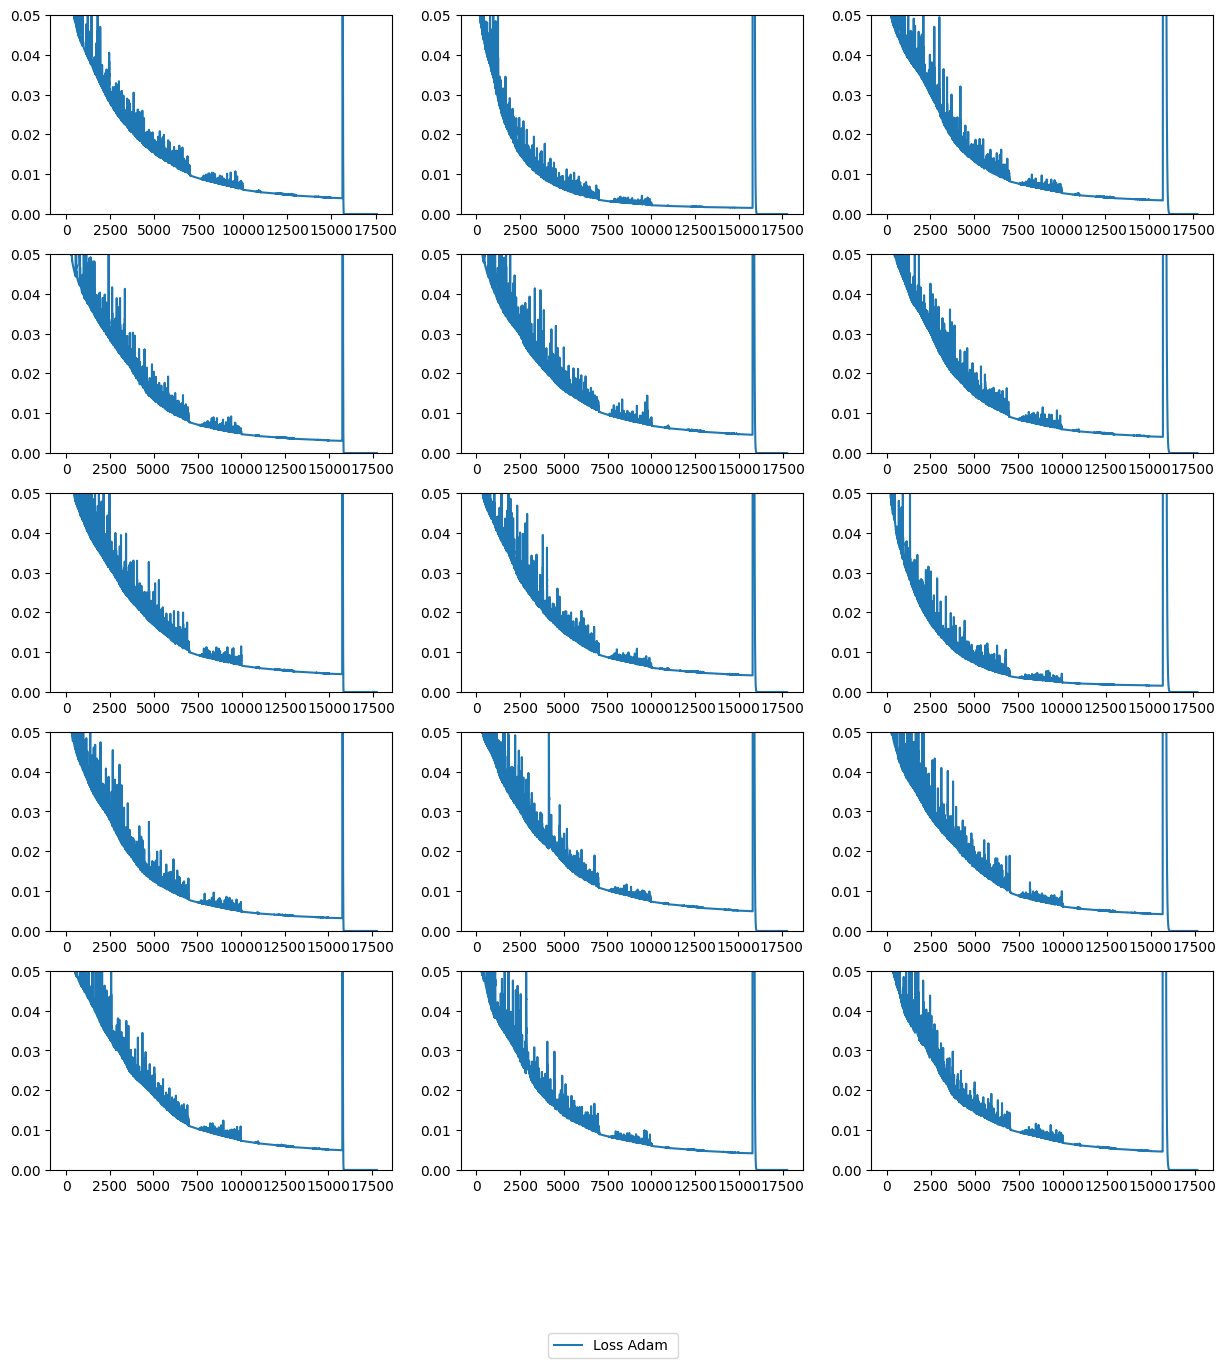

In [ ]:
# fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(15,5))

fig, axes = plt.subplots(nrows=n_models, ncols=len(initial_lambdas), figsize=(15,15))

for i in range(n_models):
  axes[i,0].plot(np.linspace(0, len(hists_Adam1[i][0].transpose()),len(hists_Adam1[i][0].transpose())), hists_Adam1[i][0].transpose())
  axes[i,0].set_ylim([0,5e-2])

  axes[i,1].plot(np.linspace(0, len(hists_Adam1[i][1].transpose()), len(hists_Adam1[i][1].transpose())), hists_Adam1[i][1].transpose())
  axes[i,1].set_ylim([0,5e-2])

  axes[i,2].plot(np.linspace(0, len(hists_Adam1[i][2].transpose()), len(hists_Adam1[i][2].transpose())), hists_Adam1[i][2].transpose())
  axes[i,2].set_ylim([0,5e-2])
  # axes[0].plot(np.linspace(0, len(hists_Adam1[i][0].transpose()),len(hists_Adam1[i][0].transpose())), hists_Adam1[i][0].transpose())
  # axes[0].set_ylim([0,1])

  # axes[1].plot(np.linspace(0, len(hists_Adam1[i][1].transpose()), len(hists_Adam1[i][1].transpose())), hists_Adam1[i][1].transpose())
  # axes[1].set_ylim([0,1])

  # axes[2].plot(np.linspace(0, len(hists_Adam1[i][2].transpose()), len(hists_Adam1[i][2].transpose())), hists_Adam1[i][2].transpose())
  # axes[2].set_ylim([0,1])


  print(f"len Atempt-{i} and init lambda {initial_lambdas[0]}: ",len(hists_Adam1[i][0].transpose()))
  print(f"len Atempt-{i} and init lambda {initial_lambdas[1]}: ",len(hists_Adam1[i][1].transpose()))
  print(f"len Atempt-{i} and init lambda {initial_lambdas[2]}: ",len(hists_Adam1[i][2].transpose()))
  # print(f"len Atempt-{i} and init lambda {initial_lambdas[3]}: ",len(hists_Adam1[i][3].transpose()))

  print("\\\\")

# timeout = 250
cols = ['$\hat{\lambda}_{1_0}^{(1)} = -1$', '$\hat{\lambda}_{1_0}^{(1)} = -2$', '$\hat{\lambda}_{1_0}^{(1)} = -5$']
rows = ['Attempt {}'.format(row) for row in range(1, n_models+1)]

# pad = 5 # in points


# for ax, col in zip(axes[0], cols):
#   ax.annotate(col, xy=(0.5, 1.05), xytext=(0, pad),
#               xycoords='axes fraction', textcoords='offset points',
#               size='large', ha='center', va='baseline')

# for ax, row in zip(axes[:,0], rows):
#   ax.annotate(row, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - pad, 0),
#               xycoords=ax.yaxis.label, textcoords='offset points',
#               size='large', ha='right', va='center')

# fig.tight_layout()

fig.legend(['Loss Adam '], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)

plt.show()

### Predict and Evaluate Inverse Problem

In [ ]:
def lambdas(hists, iter_model, iter_init):
  return hists[iter_model][iter_init][0][-1]

df = pd.DataFrame(columns=['Adam_0.5','Adam_1','Adam_1.5'])
df = df.round(10)

for i in range(n_models):
  x = []
  for j in range(len(initial_lambdas)):
    x.append(lambdas(hists_Adam, i, j))

  df.loc['Attempt '+str(i+1)] = x

print("Lambda Prediction Given U(x,t)")
df

Lambda Prediction Given U(x,t)


,Adam_0.5,Adam_1,Adam_1.5
Attempt 1,0.00001,0.00001,0.00001
Attempt 2,0.00001,0.00001,0.00001
Attempt 3,0.00001,0.00001,0.00001
Attempt 4,0.00001,0.00001,0.00001
Attempt 5,0.00001,0.00001,0.00001


In [ ]:
print(df.mean(axis=0).round(10))
df.loc['Average'] = df.mean(axis=0)


Adam_0.5    0.00001
Adam_1      0.00001
Adam_1.5    0.00001
dtype: float32


In [ ]:
df.loc['StdDev'] = df.std(axis=0, ddof=1)
df.loc['CV'] = df.loc['StdDev'] / df.loc['Average']
df.loc[['Average', 'StdDev', 'CV']] = df.loc[['Average', 'StdDev', 'CV']].round(10)
print(df.tail(3))

         Adam_0.5   Adam_1  Adam_1.5
Average   0.00001  0.00001   0.00001
StdDev    0.00000  0.00000   0.00000
CV        0.00000  0.00000   0.00000


In [ ]:
df

,Adam_0.5,Adam_1,Adam_1.5
Attempt 1,0.00001,0.00001,0.00001
Attempt 2,0.00001,0.00001,0.00001
Attempt 3,0.00001,0.00001,0.00001
Attempt 4,0.00001,0.00001,0.00001
Attempt 5,0.00001,0.00001,0.00001
Average,0.00001,0.00001,0.00001
StdDev,0.00000,0.00000,0.00000
CV,0.00000,0.00000,0.00000


## PDP Model 1 Forward

In [ ]:
n_models = 5
arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'swish', 'trainable_B':True, 'sigmas':[1.0,2.0], 'mapping_size':64}

models = [None] * n_models

for i in range(n_models):
  tf.random.set_seed(i)
  models[i] = PINN_NeuralNet(lb=lb, ub=ub, **arch)
  models[i].build((None, 3))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net_2', however 

In [ ]:
path = dir + "COModel/Fourier/Fourier_swish_fwd/"

In [ ]:
lr_comb_param = {'boundaries': [7000,10000,11000,13000,15000,20000],
                 'initial_learning_rate': 1e-2,
                 'decay_steps': 1000,
                 'decay_rate': 0.9,
                 'values_steps': 2}
lr_comb = CombinedDecays(**lr_comb_param)
lr_comb.get_config()

{'initial_learning_rate': 0.01,
 'decay_steps': 1000,
 'decay_rate': 0.9,
 'staircase': False,
 'boundaries': [7000, 10000, 11000, 13000, 15000, 20000],
 'values': [0.004782969000000001,
  0.0023914845000000003,
  0.0011957422500000002,
  0.0005978711250000001,
  0.00029893556250000004,
  0.00014946778125000002,
  7.473389062500001e-05],
 'values_steps': [2, 2, 2, 2, 2, 2],
 'name': None}

Text(0.5, 1, 'Combined Learning Rate')

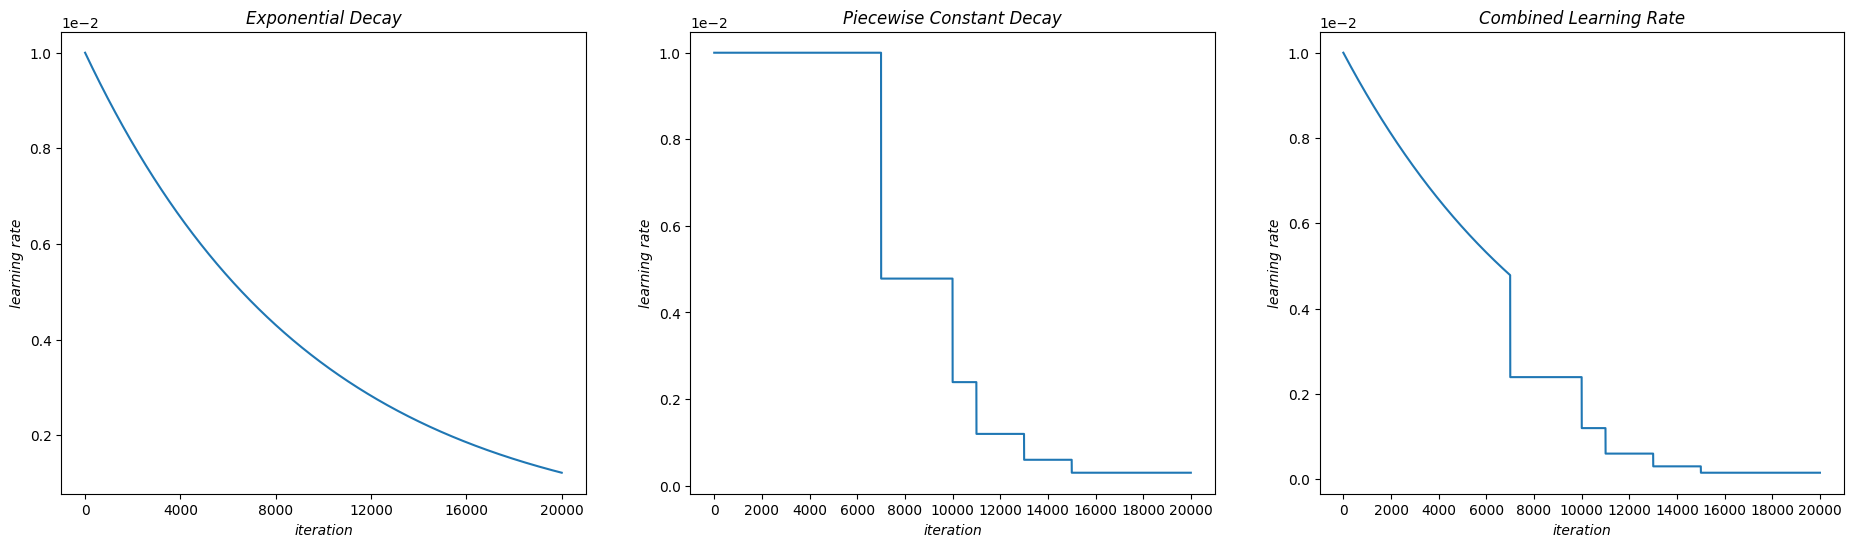

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 20000  # Extended range

fig = plt.figure(figsize=(23, 6))

# ExponentialDecay
initial_learning_rate = lr_comb.initial_learning_rate
decay_steps = lr_comb.decay_steps
decay_rate = lr_comb.decay_rate

learning_rate = []
for i in range(N+1):
    lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    learning_rate.append(lr)

plt.subplot(1, 3, 1)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 4000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Exponential Decay', y=1, fontstyle='italic')

# Piecewise Constant Decay
boundaries = lr_comb.boundaries
values = lr_comb.values

learning_rate = []
for i in range(N+1):
    for j in range(len(boundaries)):
        if i <= boundaries[0]:
            lr = lr_comb.initial_learning_rate
        elif i <= boundaries[j]:
            lr = values[j-1]
            break
        else:
            lr = values[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 2)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0, 0))
plt.title('Piecewise Constant Decay', y=1, fontstyle='italic')

# Extended Combined Decay
boundaries = lr_comb.boundaries
values_steps = lr_comb.values_steps  # should be a list like [2, 2, 2, ...]
if isinstance(values_steps, int):
    values_steps = [values_steps] * (len(boundaries))  # Make uniform if scalar

i_stop = boundaries[0]
learning_rate = []

learning_rate = []
i_stop = boundaries[0]

for i in range(N+1):
    if i <= i_stop:
        lr = initial_learning_rate * decay_rate ** (i / decay_steps)
    else:
        for j in range(1, len(boundaries)):
            if boundaries[j-1] < i <= boundaries[j]:
                if i == boundaries[j-1] + 1:
                    # first step into this boundary: decay from previous segment
                    prev_lr = learning_rate[-1]
                    lr = prev_lr / values_steps[j-1]
                else:
                    lr = learning_rate[-1]  # maintain constant
                break
        else:
            # After the last boundary
            lr = learning_rate[-1] / values_steps[-1]
    learning_rate.append(lr)

plt.subplot(1, 3, 3)
plt.plot(learning_rate)
plt.xlabel('iteration', fontstyle='italic')
plt.ylabel('learning rate', fontstyle='italic')
plt.xticks(np.arange(0, N+1, 2000))
plt.ticklabel_format(axis='y', scilimits=(0,0))
plt.title('Combined Learning Rate', y=1, fontstyle='italic')



In [ ]:
# adam_05_values = df['Adam_0.5'].values[:-3]
# adam_1_values = df['Adam_1'].values[:-3]
# adam_15_values = df['Adam_1.5'].values[:-3]

In [ ]:
pred_lambda = list(df.loc['Average'])

In [ ]:
pred_lambda

[9.999999747378752e-06, 9.999999747378752e-06, 9.999999747378752e-06]

In [ ]:
timeout = 1200
start_from = 1


models_Adam_comb = [None]*n_models
hists_Adam_comb = [None]*n_models


for i in range(start_from - 1, n_models):
    models_Adam_comb[i] = []
    hists_Adam_comb[i] = []
    for j, lambd_val in enumerate(pred_lambda):
        print('{:s}\nModel Iteration: {:d}, Lambda Iteration: {:d}\n{:s}'.format(
            50*'-', i+1, j+1, 50*'-'))

        tf.random.set_seed(i + j)  # Use a combined seed for reproducibility

        # Build and initialize model
        models_Adam_comb[i].append(PINN_NeuralNet(lb, ub, **arch))
        models_Adam_comb[i][j].build(input_shape=(None, 3))

        # Set weights and lambda from base model
        models_Adam_comb[i][j].set_weights(models[i].get_weights())
        # Prepare optimizer
        optim_Adam_comb = tf.keras.optimizers.AdamW(learning_rate=lr_comb, weight_decay =1e-3)

        # Initialize solver
        solver = PINN_PDESolver(models_Adam_comb[i][j], X_train, fun_r_fwd, get_r_fwd,lambd_val)

        # Train the model
        print('\n\nAdam - Combined Learning Rate\n')
        solver.solve_with_TFoptimizer(optim_Adam_comb, X_train, u_train, timeout=timeout)

        # Store training history
        hists_Adam_comb[i].append(solver.hist)

        print('\n\n\n')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
for i in range(n_models):
  for j in range(len(pred_lambda)):
    models_Adam_comb[i][j].save_weights(path+"_"+str(i)+"_model_Adam_comb_"+str(j)+".weights.h5", 'h5')


for i in range(n_models):
  for j in range(len(pred_lambda)):
    np.savetxt(path + "loss/hist_Adam_comb_" + str(i) + "_" + str(j) + ".csv", hists_Adam_comb[i][j], delimiter=",")

### Loss Function

len Attempt-0 Lambda ke- 0:  11388
len Attempt-0 Lambda ke- 1:  11391
len Attempt-0 Lambda ke- 2:  11387
\\
len Attempt-1 Lambda ke- 0:  11363
len Attempt-1 Lambda ke- 1:  11377
len Attempt-1 Lambda ke- 2:  11380
\\
len Attempt-2 Lambda ke- 0:  11379
len Attempt-2 Lambda ke- 1:  11375
len Attempt-2 Lambda ke- 2:  11347
\\
len Attempt-3 Lambda ke- 0:  11382
len Attempt-3 Lambda ke- 1:  11379
len Attempt-3 Lambda ke- 2:  11368
\\
len Attempt-4 Lambda ke- 0:  11363
len Attempt-4 Lambda ke- 1:  11366
len Attempt-4 Lambda ke- 2:  11354
\\


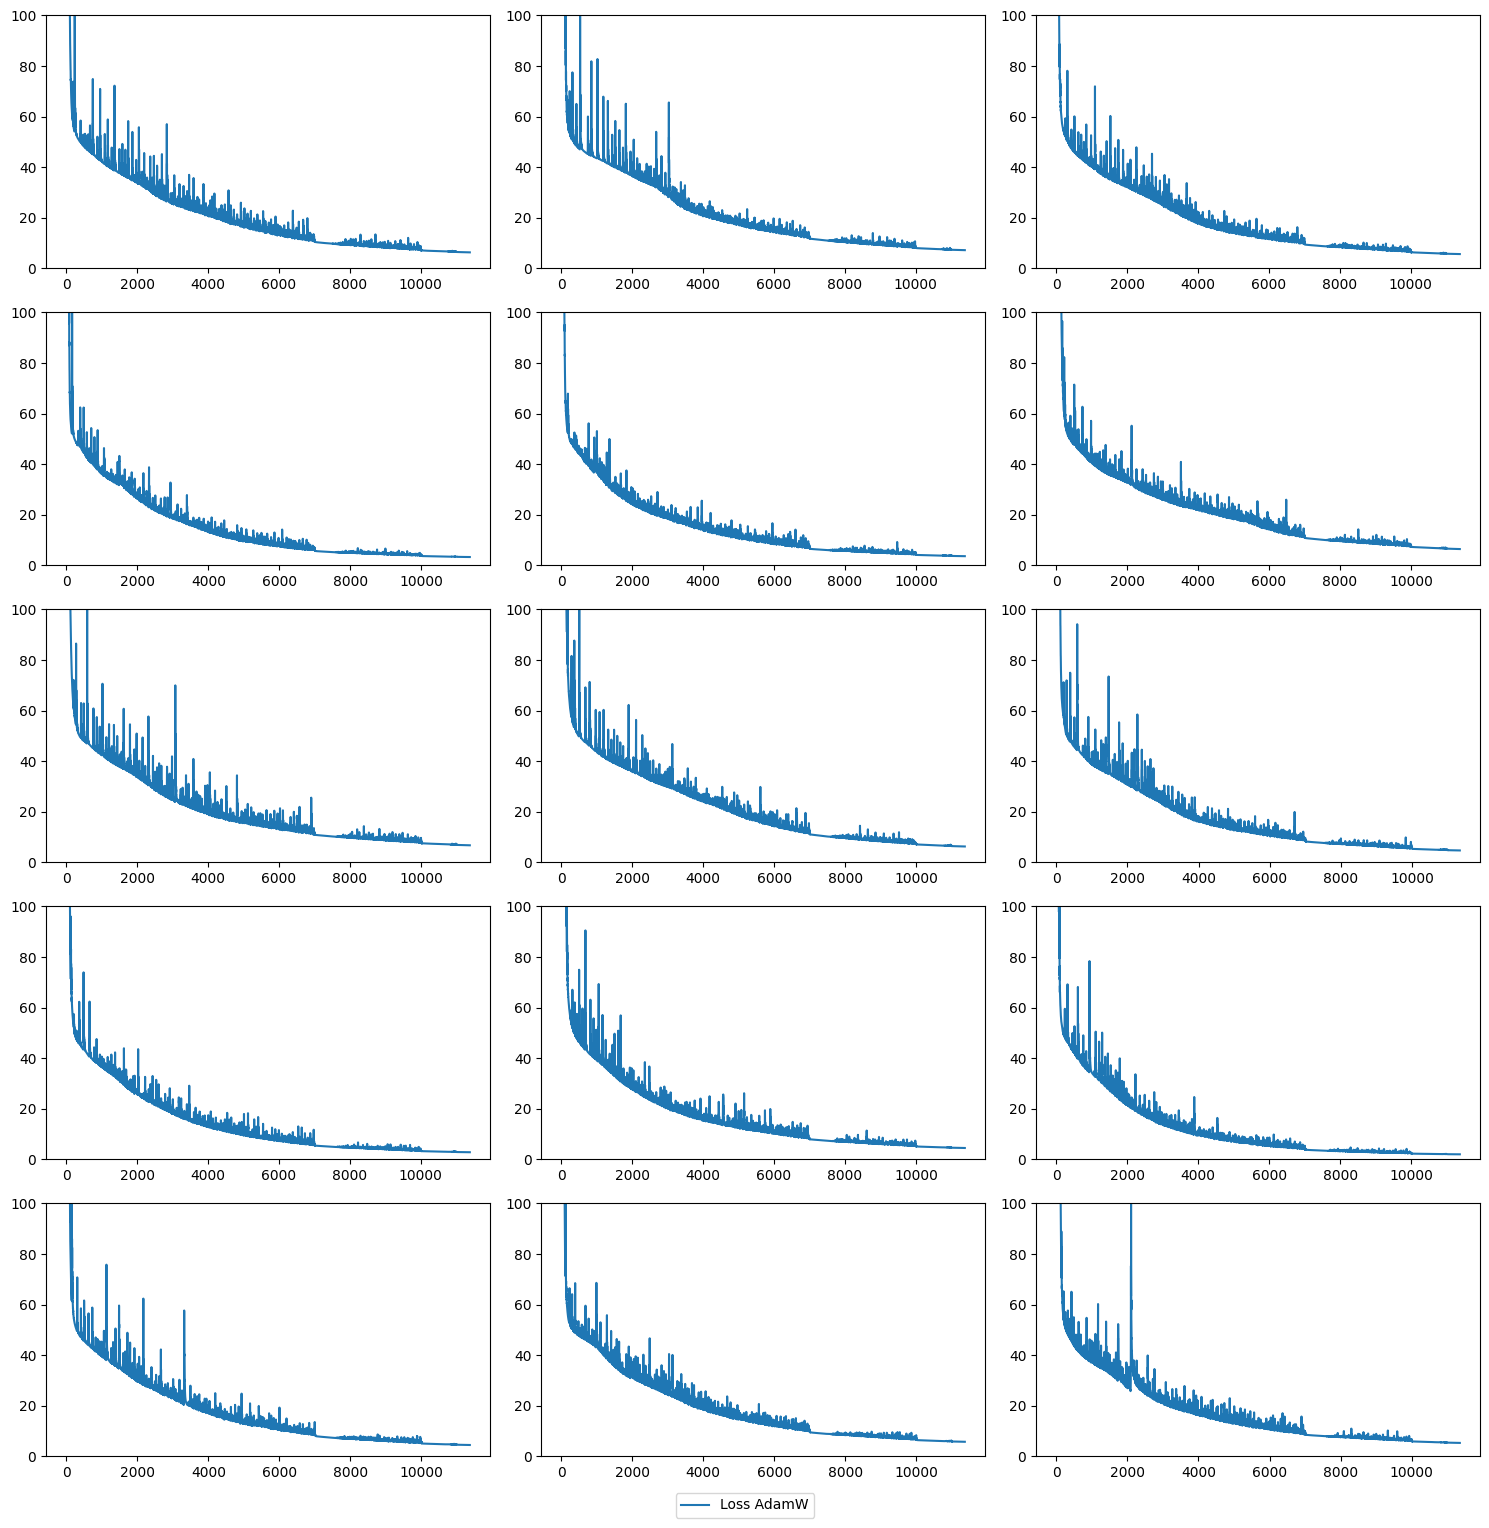

In [ ]:
fig, axes = plt.subplots(nrows=n_models, ncols=len(pred_lambda), figsize=(15, 15))

# Jika hanya 1 model, axes akan menjadi 1D array → jadikan 2D untuk konsistensi indexing
if n_models == 1:
    axes = [axes]  # bungkus agar axes[0][j] bisa digunakan

for i in range(n_models):
    for j in range(len(pred_lambda)):
        axes[i][j].plot(
            np.linspace(0, len(hists_Adam_comb[i][j]), len(hists_Adam_comb[i][j])),
            hists_Adam_comb[i][j]
        )
        axes[i][j].set_ylim([0, 1e2])
        print(f"len Attempt-{i} Lambda ke- {j}: ", len(hists_Adam_comb[i][j]))
    print("\\\\")

fig.legend(['Loss AdamW'], loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True)
plt.tight_layout()
plt.show()


### Prediction and Evaluation

In [ ]:
t_unique = np.sort(test_df['time'].unique())
x_unique = np.sort(test_df['x_coord'].unique())
y_unique = np.sort(test_df['y_coord'].unique())


In [ ]:
lb = tf.constant(lb, dtype=tf.float32)
ub = tf.constant(ub, dtype=tf.float32)

In [ ]:
train_Adam_comb = []


t_unique_train = np.sort(train_df['time'].unique())
x_unique_train = np.sort(train_df['x_coord'].unique())
y_unique_train = np.sort(train_df['y_coord'].unique())


for i in range(n_models):
  for j in range(len(pred_lambda)):
    train_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_train, t_unique_train, x_unique_train, y_unique_train))


In [ ]:
df = pd.DataFrame(columns=['Adam_0.5','Adam_1','Adam_1.5'])
initial_lambdas = [0.5,1,1.5]

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = train_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_train.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam_0.5,Adam_1,Adam_1.5
Attempt 1,"(0.06123178, 1.9314669)","(0.065015316, 2.0533295)","(0.05673132, 1.8010296)"
Attempt 2,"(0.042431332, 1.3366021)","(0.04515354, 1.4250395)","(0.061063096, 1.9187171)"
Attempt 3,"(0.06307924, 1.991763)","(0.060647607, 1.9253373)","(0.052514013, 1.6624031)"
Attempt 4,"(0.040011507, 1.267298)","(0.0502626, 1.5740142)","(0.033293936, 1.052902)"
Attempt 5,"(0.050977856, 1.6143501)","(0.05734907, 1.8094112)","(0.054737102, 1.7322752)"


In [ ]:
preds_Adam_comb = []

for i in range(n_models):
  for j in range(len(pred_lambda)):
    preds_Adam_comb.append(predict_solution(models_Adam_comb[i][j], X_test, t_unique, x_unique, y_unique))


In [ ]:
df = pd.DataFrame(columns=['Adam_0.5','Adam_1','Adam_1.5'])

# Evaluate and populate the DataFrame
for i in range(n_models):
    results = []
    for j in range(len(initial_lambdas)):
        # Evaluate solutions
        # eval_sgd = pinn.evaluate_solution(preds_SGD[i * len(initial_lambdas) + j], u_star)
        pred_t0 = preds_Adam_comb[i * len(initial_lambdas) + j]
        eval_adam = evaluate_solution(pred_t0.numpy(), u_test.numpy())

        # Append results for each lambda
        # results.append(eval_sgd)
        results.append(eval_adam)

    # Add results to DataFrame
    df.loc[f'Attempt {i+1}'] = results

# Display the DataFrame
df


,Adam_0.5,Adam_1,Adam_1.5
Attempt 1,"(0.074749194, 2.3542516)","(0.07751611, 2.448742)","(0.07140517, 2.263424)"
Attempt 2,"(0.059797958, 1.886251)","(0.06175505, 1.947907)","(0.073814295, 2.3259587)"
Attempt 3,"(0.07635754, 2.4095366)","(0.07537023, 2.3879638)","(0.067601256, 2.135051)"
Attempt 4,"(0.05867459, 1.8563997)","(0.06678905, 2.0962474)","(0.05311964, 1.6771488)"
Attempt 5,"(0.06650333, 2.1052425)","(0.07168594, 2.2605748)","(0.069973096, 2.2118185)"


In [ ]:
def summarise_attempts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a tidy table with mean, sample‑SD and CV
    for both numbers contained in each tuple cell.
    """
    summaries = {}
    for col in df.columns:
        arr = np.vstack(df[col].to_numpy())     # shape = (n_attempts, 2)
        μ  = arr.mean(axis=0)                   # mean
        σ  = arr.std(axis=0, ddof=1)            # sample SD (ddof=1)
        cv = σ / μ                              # coefficient of variation
        summaries[col] = {
            "mean_MAE": μ[0], "sd_MAE": σ[0], "cv_MAE": cv[0],
            "mean_MAPE": μ[1], "sd_MAPE": σ[1], "cv_MAPE": cv[1],
        }
    return pd.DataFrame(summaries).T

stats_df = summarise_attempts(df)
print(stats_df)

          mean_MAE    sd_MAE    cv_MAE  mean_MAPE   sd_MAPE   cv_MAPE
Adam_0.5  0.067217  0.008198  0.121959   2.122336  0.256427  0.120823
Adam_1    0.070623  0.006413  0.090810   2.228287  0.206874  0.092840
Adam_1.5  0.067183  0.008178  0.121732   2.122680  0.258712  0.121880


In [ ]:
# step  = 1e-3

# # Ambil batas bawah–atas masing‑masing kolom
# t_min, t_max = filtered_df["t"].min(),  filtered_df["t"].max()
# x_min, x_max = filtered_df["x"].min(),  filtered_df["x"].max()
# y_min, y_max = filtered_df["y"].min(),  filtered_df["y"].max()

# # --- 2.  Buat vektor titik di tiap sumbu ------------------------------------
# t_points = np.arange(t_min, t_max + step, step, dtype=np.float32)
# x_points = np.arange(x_min, x_max + step, step, dtype=np.float32)
# y_points = np.arange(y_min, y_max + step, step, dtype=np.float32)

# # Estimasi ukuran total grid  (hanya untuk info)
# total_pts = len(t_points) * len(x_points) * len(y_points)
# print(f"Grid size ≈ {total_pts:,.0f} titik; "
#       f"({len(t_points)} × {len(x_points)} × {len(y_points)})")

# # --- 3.  Fungsi pembuat batch agar irit memori ------------------------------
# def gen_batches(t_vec, x_vec, y_vec, batch_size=250_000):
#     """
#     Generator yang mengeluarkan batch array shape (N, 3)
#     agar tidak mem‑load seluruh grid sekaligus.
#     """
#     for t in t_vec:
#         # Kombinasi x–y terlebih dahulu → (len(x_points)*len(y_points), 2)
#         xy_pairs = np.stack(np.meshgrid(x_vec, y_vec, indexing="ij"), -1).reshape(-1, 2)

#         # Tambahkan kolom t
#         t_column = np.full((xy_pairs.shape[0], 1), t, dtype=np.float32)
#         tx_y     = np.hstack([t_column, xy_pairs])   # shape (N, 3)

#         # Pecah jadi mini‑batch
#         n_rows   = tx_y.shape[0]
#         n_batch  = np.math.ceil(n_rows / batch_size)
#         for i in range(n_batch):
#             start = i * batch_size
#             yield tx_y[start : start + batch_size]

# # --- 4.  Prediksi & tulis incremental ke CSV --------------------------------
# out_path = Path("prediction_grid.csv")
# header   = ["t", "x", "y"] + [f"pred_{i}" for i in range(model.output_shape[-1])]

# # Jika file sudah ada, hapus dulu supaya tidak duplikat
# out_path.unlink(missing_ok=True)

# with out_path.open("w", newline="") as f:
#     # Tulis header CSV
#     f.write(",".join(header) + "\n")

# # Loop batch‑per‑batch
# for batch in gen_batches(t_points, x_points, y_points, batch_size=250_000):
#     preds = model.predict(batch, verbose=0)    # shape (N, n_out)
#     joined = np.hstack([batch, preds])

#     # Simpan, append tanpa header
#     pd.DataFrame(joined).to_csv(out_path, mode="a", header=False, index=False)


In [ ]:
import os

# Define the directory where you want to save the CSV files
output_dir = dir + "COModel/Fourier/predictions/swish" # Assuming 'dir' is defined

for i in range(n_models):
    for j in range(len(pred_lambda)):
        # Get the prediction for the current model and initial lambda
        current_pred = preds_Adam_comb[i * len(pred_lambda) + j].numpy()

        # Create a DataFrame from the prediction
        # You might want to include time, x, and y coordinates as well
        X_test_np = X_test.numpy()

        pred_df = pd.DataFrame({
            'time': X_test_np[:, 0],
            'x_coord': X_test_np[:, 1],
            'y_coord': X_test_np[:, 2],
            'predicted_CO_mean': current_pred.flatten()
        })

        # Define the filename
        filename = f"prediction_model_{i+1}_lambda_{j+1}.csv"
        filepath = os.path.join(output_dir, filename)

        # Save the DataFrame to a CSV file
        pred_df.to_csv(filepath, index=False)

        print(f"Saved prediction to: {filepath}")

Saved prediction to: /content/drive/My Drive/TA/COModel/Fourier/predictions/swish/prediction_model_1_lambda_1.csv
Saved prediction to: /content/drive/My Drive/TA/COModel/Fourier/predictions/swish/prediction_model_1_lambda_2.csv
Saved prediction to: /content/drive/My Drive/TA/COModel/Fourier/predictions/swish/prediction_model_1_lambda_3.csv
Saved prediction to: /content/drive/My Drive/TA/COModel/Fourier/predictions/swish/prediction_model_2_lambda_1.csv
Saved prediction to: /content/drive/My Drive/TA/COModel/Fourier/predictions/swish/prediction_model_2_lambda_2.csv
Saved prediction to: /content/drive/My Drive/TA/COModel/Fourier/predictions/swish/prediction_model_2_lambda_3.csv
Saved prediction to: /content/drive/My Drive/TA/COModel/Fourier/predictions/swish/prediction_model_3_lambda_1.csv
Saved prediction to: /content/drive/My Drive/TA/COModel/Fourier/predictions/swish/prediction_model_3_lambda_2.csv
Saved prediction to: /content/drive/My Drive/TA/COModel/Fourier/predictions/swish/predic

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import numpy as np # Make sure numpy is imported for np.round
import datetime as dt
output_dir = dir + "COModel/Fourier/predictions/swish/"

# Assuming X_test, u_test, and test_df are already loaded
# Convert X_test and u_test to numpy arrays for easier manipulation if they are not already
X_test_np = X_test.numpy() if isinstance(X_test, tf.Tensor) else X_test
u_test_np = u_test.numpy().flatten() if isinstance(u_test, tf.Tensor) else u_test.flatten()

# Ensure test_df is loaded and contains the 'city' column and 'date' column
# If not, load it or make sure it's available in your environment

# Extract city names and datetime objects from the original test_df
cities = test_df['city'].values
dates = test_df['date'].dt.date.values # Assuming 'date' column is already datetime


# n_models = 5
len_pred_lambda = 3 # Assuming the number of initial lambdas is 3

# Loop through models and initial lambdas to load and plot predictions
for i in range(n_models):
    for j in range(len_pred_lambda):
        # Construct the filename
        filename = f"prediction_model_{i+1}_lambda_{j+1}.csv"
        filepath = os.path.join(output_dir, filename)

        # Load the prediction data
        try:
            pred_df = pd.read_csv(filepath)
            print(f"Loaded prediction data from: {filepath}")
        except FileNotFoundError:
            print(f"Error: File not found at {filepath}. Skipping this file.")
            continue # Skip to the next iteration if the file is not found

        # Create a DataFrame for plotting, including 'date' and 'city'
        df = pd.DataFrame({
            'date': dates,
            'city': cities,
            'u_test': u_test_np,
            'u_pred': pred_df['predicted_CO_mean'].values
        })

        # Pivot to get heatmap data using 'date' and 'city'
        heatmap_data_test = df.pivot_table(
            index='date',
            columns='city',
            values='u_test',
            aggfunc='mean' # Use mean if multiple entries for the same date and city exist
        )

        heatmap_data_pred = df.pivot_table(
            index='date',
            columns='city',
            values='u_pred',
            aggfunc='mean' # Use mean if multiple entries for the same date and city exist
        )

        # Determine shared color scale limits from the true data
        vmin = np.min(heatmap_data_test.min().min()) if not heatmap_data_test.empty else None
        vmax = np.max(heatmap_data_test.max().max()) if not heatmap_data_test.empty else None

        # Create the heatmap plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 15))

        # Plot true values with shared color scale
        if not heatmap_data_test.empty:
            sns.heatmap(heatmap_data_test, cmap='viridis', vmin=vmin, vmax=vmax, ax=ax1)
        ax1.set_title('True Values (u_test)')
        ax1.set_xlabel('City')
        ax1.set_ylabel('Date')

        # Plot predictions with shared color scale
        if not heatmap_data_pred.empty:
             sns.heatmap(heatmap_data_pred, cmap='viridis', vmin=vmin, vmax=vmax, ax=ax2)
        ax2.set_title(f'Predictions (u_pred) - Model {i+1}, Lambda {j+1}') # Dynamic title
        ax2.set_xlabel('City')
        ax2.set_ylabel('Date')

        plt.tight_layout()
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:

# Loop through models and initial lambdas to load and plot predictions
for i in range(n_models):
    for j in range(len_pred_lambda):
        # Construct the filename
        filename = f"prediction_model_{i+1}_lambda_{j+1}.csv"
        filepath = os.path.join(output_dir, filename)

        # Load the prediction data
        try:
            pred_df = pd.read_csv(filepath)
            print(f"Loaded prediction data from: {filepath}")
        except FileNotFoundError:
            print(f"Error: File not found at {filepath}. Skipping this file.")
            continue # Skip to the next iteration if the file is not found

        # Create a DataFrame for plotting, including 'date' and 'city'
        df_recap = pd.DataFrame({
            'date': dates,
            'city': cities,
            'u_test': u_test_np,
            'u_pred': pred_df['predicted_CO_mean'].values
        })
        nrows = 10
        ncols= 5
        unique_cities = df_recap['city'].unique()
        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
        axes = axes.flatten() # Flatten the axes array for easy indexing

        # Iterate through unique cities and plot on their respective subplots
        for city_idx, city in enumerate(unique_cities):
            city_df = df_recap[df_recap['city'] == city].copy()

            sns.lineplot(data=city_df, x='date', y='u_test', label='True', ax=axes[city_idx])
            sns.lineplot(data=city_df, x='date', y='u_pred', label='Predicted', ax=axes[city_idx])

            axes[city_idx].set_title(f'{city}')
            axes[city_idx].set_xlabel('Date')
            axes[city_idx].set_ylabel('CO Mean')
            axes[city_idx].tick_params(axis='x', rotation=45)
            axes[city_idx].grid(True)
            axes[city_idx].legend()

        # Hide any unused subplots if the number of cities is not a multiple of ncols
        for k in range(41, nrows * ncols):
            fig.delaxes(axes[k])

        fig.suptitle(f'CO Mean Over Time (Model-{i+1}, Lambda-{j+1})', fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

# Ekspor Hasil Prediksi Semua Titik dari Model Terbaik setiap Inisial Lambda

In [ ]:
weights = models_Adam_comb[3][0].get_weights()

for i, w in enumerate(weights):
    print(f"Weight {i}: shape = {w.shape}")
    print(w)

Weight 0: shape = (3, 64)
[[ 1.06483722e+00  2.40208395e-02 -7.09903538e-01  1.57205296e+00
   1.54417646e+00 -1.46557763e-01  2.15770960e+00  3.85991484e-01
  -1.05461156e+00 -1.07213891e+00 -1.14354575e+00 -9.65526819e-01
   4.17964965e-01  8.19041669e-01 -2.53177345e-01  3.09328973e-01
   1.25458539e+00  8.01998794e-01 -1.13551044e+00  4.59273279e-01
   5.08183956e-01 -1.04818380e+00 -6.81433856e-01  1.15640748e+00
   2.54961276e+00  6.30022347e-01 -1.33430615e-01 -7.60303140e-01
  -1.16611075e+00 -8.85613680e-01 -8.60872388e-01 -2.57657409e-01
   1.66951323e+00  2.14255428e+00 -2.00492525e+00  3.55492949e-01
  -7.16405928e-01  1.28403854e+00 -2.92738652e+00 -1.21443653e+00
  -1.49494696e+00  9.81422782e-01  1.74474001e+00  7.29203522e-02
   5.39217830e-01  1.36948431e+00 -4.78940278e-01 -1.18315542e+00
   2.40612936e+00 -1.24430728e+00  1.05423415e+00 -8.40817541e-02
   3.93218696e-01  1.09912705e+00 -2.22098920e-03  4.35169578e-01
   1.89075553e+00  9.46131766e-01  1.59432685e+00 

In [ ]:
weights2 = models_Adam_comb[1][1].get_weights()

for i, w in enumerate(weights2):
    print(f"Weight {i}: shape = {w.shape}")
    print(w)

Weight 0: shape = (3, 64)
[[ 1.08175313e+00 -6.60613358e-01 -1.72118020e+00  2.11104178e+00
  -6.65212512e-01 -8.26367021e-01  4.75019366e-01  3.71530414e-01
   6.33318305e-01  9.84160006e-01 -7.66312897e-01  4.26836222e-01
   3.50227475e-01 -3.10005999e+00  2.37947926e-01 -9.46860313e-01
   1.13534486e+00  1.73326647e+00  1.36128336e-01 -1.25799537e+00
  -6.13807559e-01  1.44449019e+00 -2.69292235e+00  3.73143315e-01
  -2.72580296e-01 -8.82152915e-01 -3.54891419e-02 -3.63332272e-01
  -8.10438156e-01 -4.98196125e-01  1.70073414e+00 -6.37966573e-01
   3.18808317e-01  1.35922039e+00 -3.15534174e-01 -1.06515479e+00
   5.04255056e-01  1.34661138e+00 -3.27668285e+00 -1.46921313e+00
   1.63378096e+00  7.36387670e-01  1.42578840e+00 -1.19817400e+00
   1.40341771e+00 -1.00912973e-01  3.12228471e-01  4.14478481e-01
   6.10036910e-01 -5.12706518e-01 -9.77765843e-02 -3.36936980e-01
   5.90863466e-01 -1.11497402e+00 -2.03539658e+00  2.53847599e+00
  -8.22318256e-01  6.87447429e-01  2.12797418e-01 

In [ ]:
weights3 = models_Adam_comb[3][2].get_weights()

for i, w in enumerate(weights3):
    print(f"Weight {i}: shape = {w.shape}")
    print(w)

Weight 0: shape = (3, 64)
[[-3.9681995e-01  2.1708102e+00  1.9514246e+00 -1.4513465e+00
  -1.4442358e+00 -5.5079824e-01 -2.3429935e+00  8.0168229e-01
  -7.8752649e-01  1.6461743e+00 -1.9380596e+00  1.5596594e+00
  -3.9196862e-03 -6.0302883e-01  7.5990874e-01 -7.5452799e-01
   2.3468660e-01 -1.2157413e+00  1.7647679e+00  5.3469259e-01
  -6.4028758e-01 -1.5916361e+00 -7.9463595e-01 -4.2166695e-01
   8.2300949e-01  7.4625492e-01 -8.7970793e-01  7.8316790e-01
  -6.2955928e-01  2.0601356e-01 -4.9819697e-02 -1.7495439e+00
   2.9793584e-01  1.1483004e+00 -1.6383616e+00  2.6531999e+00
  -8.2936779e-02 -9.0158933e-01 -9.9021149e-01  1.7470112e+00
   3.0041162e-03  3.1802264e-01  2.3412356e+00  1.3247793e+00
   8.5125065e-01 -6.8253952e-01  3.6899608e-01 -1.2059809e+00
   4.1479397e-01  1.5858056e-01 -7.0414048e-01 -1.5915251e+00
  -1.6487380e+00  3.2105317e+00  2.2242224e+00  1.9680403e+00
   2.5385475e+00 -8.2744014e-01  1.5392412e+00 -1.3852628e+00
   2.1345744e+00 -4.3746376e-01  1.3105867e+

In [ ]:
# import numpy as np
# import pandas as pd
# import math
# import os
# from google.colab import files

# # --- 1. Load data dan siapkan grid (1e-4 spacing) ---

# # Misal Anda sudah memiliki filtered_df
# # Jika belum, upload:
# # uploaded = files.upload()
# # filtered_df = pd.read_csv("filtered_df.csv")

# step = 1e-2  # Resolusi

# t_min, t_max = filtered_df["time"].min(), filtered_df["time"].max()
# x_min, x_max = filtered_df["x_coord"].min(), filtered_df["x_coord"].max()
# y_min, y_max = filtered_df["y_coord"].min(), filtered_df["y_coord"].max()

# t_points = np.arange(t_min, t_max + step, 1, dtype=np.float32)
# x_points = np.arange(x_min, x_max + step, step, dtype=np.float32)
# y_points = np.arange(y_min, y_max + step, step, dtype=np.float32)


# target_indices = [(3, 0), (0, 1), (4, 2)]
# models_to_use  = [models_Adam_comb[i][j] for i, j in target_indices]
# model_labels   = [f"m{i}_{j}" for i, j in target_indices]
# file_paths     = [f"/content/prediction_{label}.csv" for label in model_labels]

# # --- 3. Generator grid untuk batch prediksi ---

# def gen_batches(t_vec, x_vec, y_vec, batch_size=250_000):
#     for t in t_vec:
#         xy_pairs = np.stack(np.meshgrid(x_vec, y_vec, indexing="ij"), -1).reshape(-1, 2)
#         t_col = np.full((xy_pairs.shape[0], 1), t, dtype=np.float32)
#         tx_y = np.hstack([t_col, xy_pairs])
#         n_rows = tx_y.shape[0]
#         n_batch = math.ceil(n_rows / batch_size)
#         for k in range(n_batch):
#             yield tx_y[k * batch_size : (k + 1) * batch_size]

# # --- 4. Buat 3 file kosong dengan header masing-masing ---

# for path in file_paths:
#     if os.path.exists(path):
#         os.remove(path)
#     with open(path, "w") as f:
#         f.write("t,x,y,prediction\n")  # header standar

# # --- 5. Proses batch demi batch dan tulis per model ke file masing-masing ---

# for batch in gen_batches(t_points, x_points, y_points):
#     for model, path in zip(models_to_use, file_paths):
#         pred = model.predict(batch, verbose=0).reshape(-1, 1)  # asumsi 1 kolom
#         output = np.hstack([batch, pred])
#         pd.DataFrame(output, columns=["t", "x", "y", "prediction"])\
#           .to_csv(path, mode="a", header=False, index=False, float_format="%.6g")



KeyboardInterrupt: 

# Reconstruction and Imputation

In [35]:
import tensorflow as tf
import os

# Assuming 'arch' and 'lb', 'ub' are defined in previous cells
# Assuming 'n_models' and 'pred_lambda' are defined

# Create the models with the correct architecture
pred_lambda = [0.5]
n_models=5
models_Adam_comb = [[None for _ in range(len(pred_lambda))] for _ in range(n_models)]

# Load the weights into the specified model
i = 3
j = 0
arch = {'output_dim':1, 'num_hidden_layers':5, 'num_neurons_per_layer':100,'activation':'swish', 'trainable_B':True, 'sigmas':[1.0,2.0], 'mapping_size':64}

path = dir + 'COModel/Fourier/Fourier_swish_fwd/'

# Create the model instance
models_Adam_comb[i][j] = PINN_NeuralNet(lb=lb, ub=ub, **arch)

# Build the model (important before loading weights)
models_Adam_comb[i][j].build((None, 3))
# A dummy forward pass is sometimes needed to fully build the model before loading weights
_ = models_Adam_comb[i][j](tf.zeros((1, 3)))

# Construct the filename
filename = f"_{i}_model_Adam_comb_{j}.weights.h5"
filepath = os.path.join(path, filename)

# Load the weights into the model
try:
    models_Adam_comb[i][j].load_weights(filepath)
    print(f"Loaded weights for model {i+1}, lambda {j+1} from: {filepath}")
except FileNotFoundError:
    print(f"Error: Weight file not found at {filepath}. Skipping.")
except Exception as e:
    print(f"An error occurred while loading weights from {filepath}: {e}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'pinn__neural_net', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Loaded weights for model 4, lambda 1 from: /content/drive/My Drive/TA/COModel/Fourier/Fourier_swish_fwd/_3_model_Adam_comb_0.weights.h5


In [36]:
models_Adam_comb[3][0].get_weights()

[array([[ 1.06483722e+00,  2.40208395e-02, -7.09903538e-01,
          1.57205296e+00,  1.54417646e+00, -1.46557763e-01,
          2.15770960e+00,  3.85991484e-01, -1.05461156e+00,
         -1.07213891e+00, -1.14354575e+00, -9.65526819e-01,
          4.17964965e-01,  8.19041669e-01, -2.53177345e-01,
          3.09328973e-01,  1.25458539e+00,  8.01998794e-01,
         -1.13551044e+00,  4.59273279e-01,  5.08183956e-01,
         -1.04818380e+00, -6.81433856e-01,  1.15640748e+00,
          2.54961276e+00,  6.30022347e-01, -1.33430615e-01,
         -7.60303140e-01, -1.16611075e+00, -8.85613680e-01,
         -8.60872388e-01, -2.57657409e-01,  1.66951323e+00,
          2.14255428e+00, -2.00492525e+00,  3.55492949e-01,
         -7.16405928e-01,  1.28403854e+00, -2.92738652e+00,
         -1.21443653e+00, -1.49494696e+00,  9.81422782e-01,
          1.74474001e+00,  7.29203522e-02,  5.39217830e-01,
          1.36948431e+00, -4.78940278e-01, -1.18315542e+00,
          2.40612936e+00, -1.24430728e+0

In [ ]:
import numpy as np
import pandas as pd
import math
import os
from google.colab import files
from concurrent.futures import ThreadPoolExecutor

# --- 1. Load data dan siapkan grid (1e-4 spacing) ---

# Misal Anda sudah memiliki filtered_df
# Jika belum, upload:
# uploaded = files.upload()
# filtered_df = pd.read_csv("filtered_df.csv")

step = 1e-2  # Resolusi

t_min, t_max = filtered_df["time"].min(), filtered_df["time"].max()
x_min, x_max = filtered_df["x_coord"].min(), filtered_df["x_coord"].max()
y_min, y_max = filtered_df["y_coord"].min(), filtered_df["y_coord"].max()

t_points = np.arange(t_min, t_max + step, 1, dtype=np.float32)
x_points = np.arange(x_min, x_max + step, step, dtype=np.float32)
y_points = np.arange(y_min, y_max + step, step, dtype=np.float32)

len(t_points)*len(x_points)*len(y_points)

69134650

In [ ]:
# --- 2. Pilih model dan path hasil ---
target_indices = [(3, 0)]  # sesuaikan
models_to_use  = [models_Adam_comb[i][j] for i, j in target_indices]
model_labels   = [f"m{i}_{j}" for i, j in target_indices]
file_paths     = [f"/content/prediction_{label}.csv" for label in model_labels]

# --- 3. Buat file output kosong dengan header ---
for path in file_paths:
    if os.path.exists(path):
        os.remove(path)
    with open(path, "w") as f:
        f.write("t,x,y,prediction\n")

# --- 4. Precompute spatial meshgrid (xy pairs) sekali saja ---
xy_pairs = np.stack(np.meshgrid(x_points, y_points, indexing="ij"), -1).reshape(-1, 2)

# --- 5. Fungsi batch generator ---
def gen_batches(t_vec, batch_size=1_000_000):
    for t in t_vec:
        t_col = np.full((xy_pairs.shape[0], 1), t, dtype=np.float32)
        tx_y = np.hstack([t_col, xy_pairs])
        n_rows = tx_y.shape[0]
        n_batch = math.ceil(n_rows / batch_size)
        for k in range(n_batch):
            yield t, tx_y[k * batch_size : (k + 1) * batch_size]

# --- 6. Fungsi prediksi + tulis ke file ---
def predict_and_write(model, batch, path):
    pred = model.predict_on_batch(batch).reshape(-1, 1)
    output = np.hstack([batch, pred])
    df = pd.DataFrame(output, columns=["t", "x", "y", "prediction"])
    df.to_csv(path, mode="a", header=False, index=False, float_format="%.6g")

# --- 7. Loop utama: batch per waktu + paralel tulis model ---
for t_val, batch in gen_batches(t_points):
    print(f"Processing time: {t_val}, Batch shape: {batch.shape}")
    with ThreadPoolExecutor() as executor:
        for model, path in zip(models_to_use, file_paths):
            executor.submit(predict_and_write, model, batch, path)

Processing time: 0.0, Batch shape: (94705, 3)
Processing time: 1.0, Batch shape: (94705, 3)
Processing time: 2.0, Batch shape: (94705, 3)
Processing time: 3.0, Batch shape: (94705, 3)
Processing time: 4.0, Batch shape: (94705, 3)
Processing time: 5.0, Batch shape: (94705, 3)
Processing time: 6.0, Batch shape: (94705, 3)
Processing time: 7.0, Batch shape: (94705, 3)
Processing time: 8.0, Batch shape: (94705, 3)
Processing time: 9.0, Batch shape: (94705, 3)
Processing time: 10.0, Batch shape: (94705, 3)
Processing time: 11.0, Batch shape: (94705, 3)
Processing time: 12.0, Batch shape: (94705, 3)
Processing time: 13.0, Batch shape: (94705, 3)
Processing time: 14.0, Batch shape: (94705, 3)
Processing time: 15.0, Batch shape: (94705, 3)
Processing time: 16.0, Batch shape: (94705, 3)
Processing time: 17.0, Batch shape: (94705, 3)
Processing time: 18.0, Batch shape: (94705, 3)
Processing time: 19.0, Batch shape: (94705, 3)
Processing time: 20.0, Batch shape: (94705, 3)
Processing time: 21.0, 

In [37]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd

prediction_df = pd.read_csv("/content/drive/MyDrive/TA/Reconstruction/SeluruhWilayah_CO_M3_Swish.csv")
prediction_cleaned_df =prediction_df.copy()
# Replace negative values in the 'prediction' column with 9
prediction_cleaned_df['prediction'] = prediction_df['prediction'].apply(lambda x: 0 if x < 0 else x)

prediction_df


,t,x,y,prediction
0,0,104.968,-7.96479,2.109720
1,0,104.968,-7.95479,2.122200
2,0,104.968,-7.94479,2.138670
3,0,104.968,-7.93479,2.159290
4,0,104.968,-7.92479,2.183850
...,...,...,...,...
69134645,729,108.989,-5.66474,0.026152
69134646,729,108.989,-5.65474,0.333976
69134647,729,108.989,-5.64474,0.586556
69134648,729,108.989,-5.63474,0.793852


In [38]:
from datetime import datetime, timedelta

# --- Step 1: Define the start date ---
start_date = datetime(2023, 5, 1)  # Fixed starting date

# --- Step 2: Input your target date ---
# Example: input day, month, year
target_day = 1
target_month = 10
target_year = 2024

# --- Step 3: Create the target date object ---
target_date = datetime(target_year, target_month, target_day)

# --- Step 4: Compute the number of days since start_date ---
t = (target_date - start_date).days

# --- Step 5: Print the result ---
print("t =", t)


t = 519


Filtered prediction data for time = 519. Shape: (94705, 4)


,t,x,y,prediction
49151895,519,104.968,-7.96479,2.84874
49151896,519,104.968,-7.95479,2.98111
49151897,519,104.968,-7.94479,3.09147
49151898,519,104.968,-7.93479,3.18108
49151899,519,104.968,-7.92479,3.25163



Merged GeoDataFrame:


/tmp/ipython-input-3098960159.py:29: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(prediction_gdf, jawa, how="inner", predicate="within")


,t,x,y,prediction,geometry,index_right,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2
49155555,519,105.118,-6.61476,4.25196,POINT (105.118 -6.61476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
49155556,519,105.118,-6.60476,4.23452,POINT (105.118 -6.60476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
49155790,519,105.129,-6.61476,4.23133,POINT (105.129 -6.61476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
49155791,519,105.129,-6.60476,4.21674,POINT (105.129 -6.60476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
49155792,519,105.129,-6.59476,4.20294,POINT (105.129 -6.59476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA


/tmp/ipython-input-3098960159.py:46: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  jawa['centroid'] = jawa.geometry.centroid
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


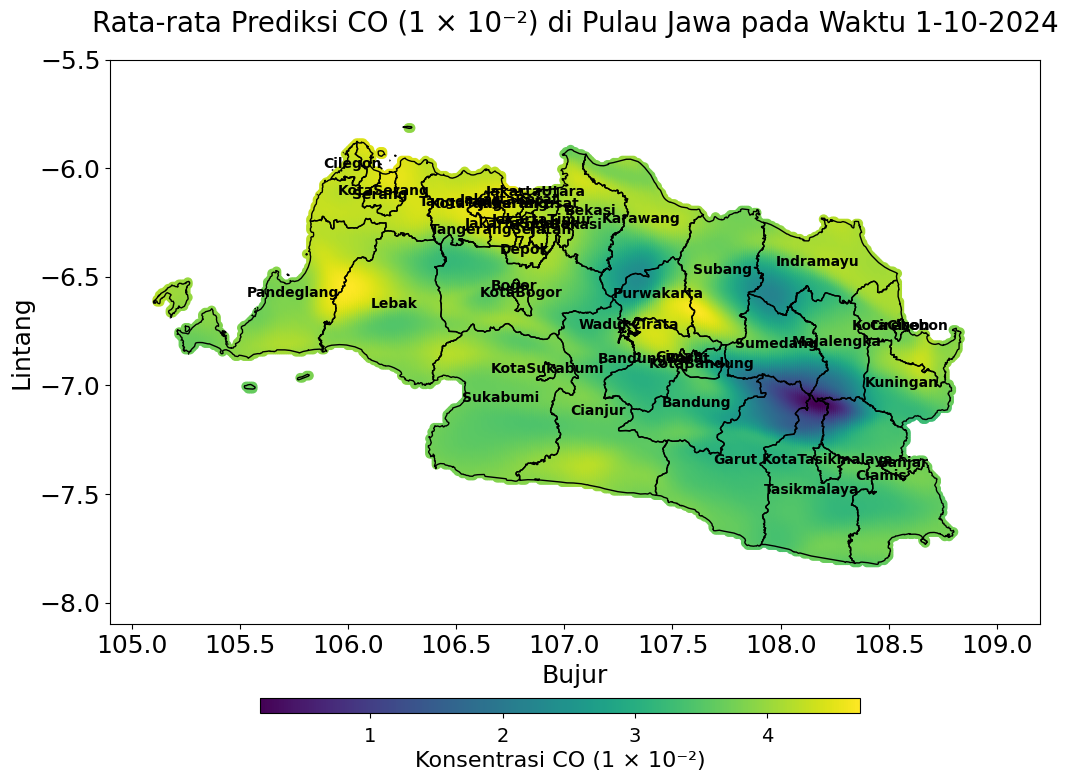

In [39]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd
import matplotlib as mpl
import matplotlib.patheffects as pe

# --- 2. Filter Data by Time ---
# Choose a specific time 't' to visualize
time_to_visualize = t  # Example: Visualize predictions at time step 365

filtered_prediction_df = prediction_df[prediction_df['t'] == time_to_visualize].copy()
if filtered_prediction_df.empty:
    print(f"No prediction data found for time = {time_to_visualize}.")
else:
    print(f"Filtered prediction data for time = {time_to_visualize}. Shape: {filtered_prediction_df.shape}")
    display(filtered_prediction_df.head())

    # --- 3. Prepare Geographical Data ---
    indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

    jawa_provinces = df.city.unique()
    jawa = indonesia[indonesia['NAME_2'].isin(jawa_provinces)]

    # --- 4. Merge Data ---
    geometry = [Point(xy) for xy in zip(filtered_prediction_df['x'], filtered_prediction_df['y'])]
    prediction_gdf = gpd.GeoDataFrame(filtered_prediction_df, geometry=geometry)

    merged_gdf = gpd.sjoin(prediction_gdf, jawa, how="inner", predicate="within")

    print("\nMerged GeoDataFrame:")
    display(merged_gdf.head())

    # --- 5. Visualize Predictions ---
    fig, ax = plt.subplots(figsize=(12,7.5))

    # Plot Java map
    jawa.plot(ax=ax, color='lightgray', edgecolor='black')

    # Plot predicted NO₂
    if not merged_gdf.empty:
        merged_gdf.plot(column='prediction', ax=ax, cmap='viridis')

    # --- Draw boundaries and add labels ---
    jawa.boundary.plot(ax=ax, color='black', linewidth=1)
    jawa['centroid'] = jawa.geometry.centroid

    for idx, row in jawa.iterrows():
        ax.annotate(
            text=row['NAME_2'],
            xy=(row['centroid'].x, row['centroid'].y),
            ha='center',
            fontsize=10,
            color='black',
            weight='bold'
        )

    # --- Colorbar ---
    cax = fig.add_axes([0.25, 0, 0.5, 0.02])  # [left, bottom, width, height]
    sm = plt.cm.ScalarMappable(
        cmap='viridis',
        norm=plt.Normalize(vmin=merged_gdf['prediction'].min(),
                           vmax=merged_gdf['prediction'].max())
    )
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.set_label('Konsentrasi CO (1 × 10⁻²)', fontsize=16)
    cbar.ax.tick_params(labelsize=14,pad=6)

    # --- Titles and labels ---
    ax.set_title(
        f'Rata-rata Prediksi CO (1 × 10⁻²) di Pulau Jawa pada Waktu {target_day}-{target_month}-{target_year}',
        fontsize=20, pad=20
    )
    ax.set_xlabel('Bujur', fontsize=18)
    ax.set_ylabel('Lintang', fontsize=18)
    ax.tick_params(axis='both', labelsize=18)

    # --- Region limits ---
    ax.set_xlim(104.9, 109.2)
    ax.set_ylim(-8.1, -5.5)

    plt.show()


In [40]:
from datetime import datetime, timedelta

# --- Step 1: Define the start date ---
start_date = datetime(2023, 5, 1)  # Fixed starting date

# --- Step 2: Input your target date ---
# Example: input day, month, year
target_day = 1
target_month = 4
target_year = 2025

# --- Step 3: Create the target date object ---
target_date = datetime(target_year, target_month, target_day)

# --- Step 4: Compute the number of days since start_date ---
t = (target_date - start_date).days

# --- Step 5: Print the result ---
print("t =", t)


t = 701


Filtered prediction data for time = 701. Shape: (94705, 4)


,t,x,y,prediction
66388205,701,104.968,-7.96479,3.10316
66388206,701,104.968,-7.95479,3.04236
66388207,701,104.968,-7.94479,2.97982
66388208,701,104.968,-7.93479,2.91881
66388209,701,104.968,-7.92479,2.86250



Merged GeoDataFrame:


/tmp/ipython-input-3098960159.py:29: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(prediction_gdf, jawa, how="inner", predicate="within")


,t,x,y,prediction,geometry,index_right,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2
66391865,701,105.118,-6.61476,2.49185,POINT (105.118 -6.61476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
66391866,701,105.118,-6.60476,2.50231,POINT (105.118 -6.60476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
66392100,701,105.129,-6.61476,2.49948,POINT (105.129 -6.61476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
66392101,701,105.129,-6.60476,2.50963,POINT (105.129 -6.60476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
66392102,701,105.129,-6.59476,2.51882,POINT (105.129 -6.59476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA


/tmp/ipython-input-3098960159.py:46: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  jawa['centroid'] = jawa.geometry.centroid
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


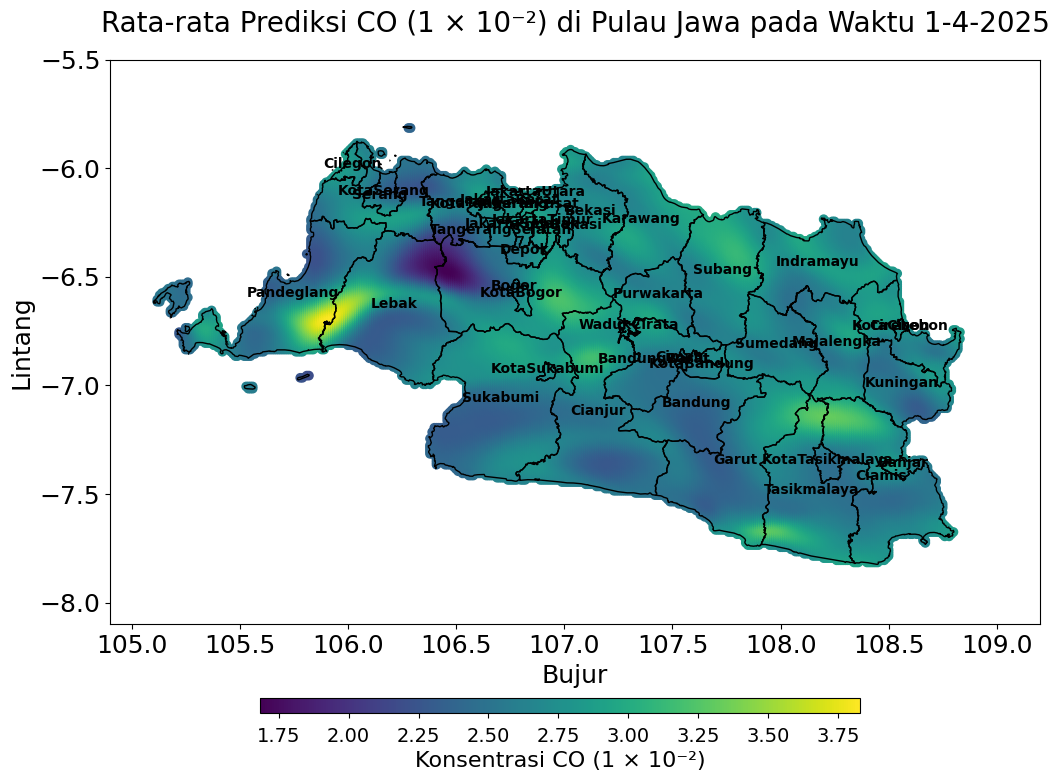

In [41]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd
import matplotlib as mpl
import matplotlib.patheffects as pe

# --- 2. Filter Data by Time ---
# Choose a specific time 't' to visualize
time_to_visualize = t  # Example: Visualize predictions at time step 365

filtered_prediction_df = prediction_df[prediction_df['t'] == time_to_visualize].copy()
if filtered_prediction_df.empty:
    print(f"No prediction data found for time = {time_to_visualize}.")
else:
    print(f"Filtered prediction data for time = {time_to_visualize}. Shape: {filtered_prediction_df.shape}")
    display(filtered_prediction_df.head())

    # --- 3. Prepare Geographical Data ---
    indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

    jawa_provinces = df.city.unique()
    jawa = indonesia[indonesia['NAME_2'].isin(jawa_provinces)]

    # --- 4. Merge Data ---
    geometry = [Point(xy) for xy in zip(filtered_prediction_df['x'], filtered_prediction_df['y'])]
    prediction_gdf = gpd.GeoDataFrame(filtered_prediction_df, geometry=geometry)

    merged_gdf = gpd.sjoin(prediction_gdf, jawa, how="inner", predicate="within")

    print("\nMerged GeoDataFrame:")
    display(merged_gdf.head())

    # --- 5. Visualize Predictions ---
    fig, ax = plt.subplots(figsize=(12,7.5))

    # Plot Java map
    jawa.plot(ax=ax, color='lightgray', edgecolor='black')

    # Plot predicted NO₂
    if not merged_gdf.empty:
        merged_gdf.plot(column='prediction', ax=ax, cmap='viridis')

    # --- Draw boundaries and add labels ---
    jawa.boundary.plot(ax=ax, color='black', linewidth=1)
    jawa['centroid'] = jawa.geometry.centroid

    for idx, row in jawa.iterrows():
        ax.annotate(
            text=row['NAME_2'],
            xy=(row['centroid'].x, row['centroid'].y),
            ha='center',
            fontsize=10,
            color='black',
            weight='bold'
        )

    # --- Colorbar ---
    cax = fig.add_axes([0.25, 0, 0.5, 0.02])  # [left, bottom, width, height]
    sm = plt.cm.ScalarMappable(
        cmap='viridis',
        norm=plt.Normalize(vmin=merged_gdf['prediction'].min(),
                           vmax=merged_gdf['prediction'].max())
    )
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.set_label('Konsentrasi CO (1 × 10⁻²)', fontsize=16)
    cbar.ax.tick_params(labelsize=14,pad=6)

    # --- Titles and labels ---
    ax.set_title(
        f'Rata-rata Prediksi CO (1 × 10⁻²) di Pulau Jawa pada Waktu {target_day}-{target_month}-{target_year}',
        fontsize=20, pad=20
    )
    ax.set_xlabel('Bujur', fontsize=18)
    ax.set_ylabel('Lintang', fontsize=18)
    ax.tick_params(axis='both', labelsize=18)

    # --- Region limits ---
    ax.set_xlim(104.9, 109.2)
    ax.set_ylim(-8.1, -5.5)

    plt.show()


In [42]:
from datetime import datetime, timedelta

# --- Step 1: Define the start date ---
start_date = datetime(2023, 5, 1)  # Fixed starting date

# --- Step 2: Input your target date ---
# Example: input day, month, year
target_day = 26
target_month = 4
target_year = 2025

# --- Step 3: Create the target date object ---
target_date = datetime(target_year, target_month, target_day)

# --- Step 4: Compute the number of days since start_date ---
t = (target_date - start_date).days

# --- Step 5: Print the result ---
print("t =", t)


t = 726


Filtered prediction data for time = 726. Shape: (94705, 4)


,t,x,y,prediction
68755830,726,104.968,-7.96479,2.97871
68755831,726,104.968,-7.95479,2.98595
68755832,726,104.968,-7.94479,2.98385
68755833,726,104.968,-7.93479,2.97308
68755834,726,104.968,-7.92479,2.95560



Merged GeoDataFrame:


/tmp/ipython-input-3098960159.py:29: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  merged_gdf = gpd.sjoin(prediction_gdf, jawa, how="inner", predicate="within")


,t,x,y,prediction,geometry,index_right,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2
68759490,726,105.118,-6.61476,2.83474,POINT (105.118 -6.61476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
68759491,726,105.118,-6.60476,2.83832,POINT (105.118 -6.60476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
68759725,726,105.129,-6.61476,2.85633,POINT (105.129 -6.61476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
68759726,726,105.129,-6.60476,2.86237,POINT (105.129 -6.60476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA
68759727,726,105.129,-6.59476,2.86720,POINT (105.129 -6.59476),43,IDN.4.5_1,IDN,Indonesia,IDN.4_1,Banten,NA,Pandeglang,NA,NA,Kabupaten,Regency,3601,ID.BT.PA


/tmp/ipython-input-3098960159.py:46: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  jawa['centroid'] = jawa.geometry.centroid
/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


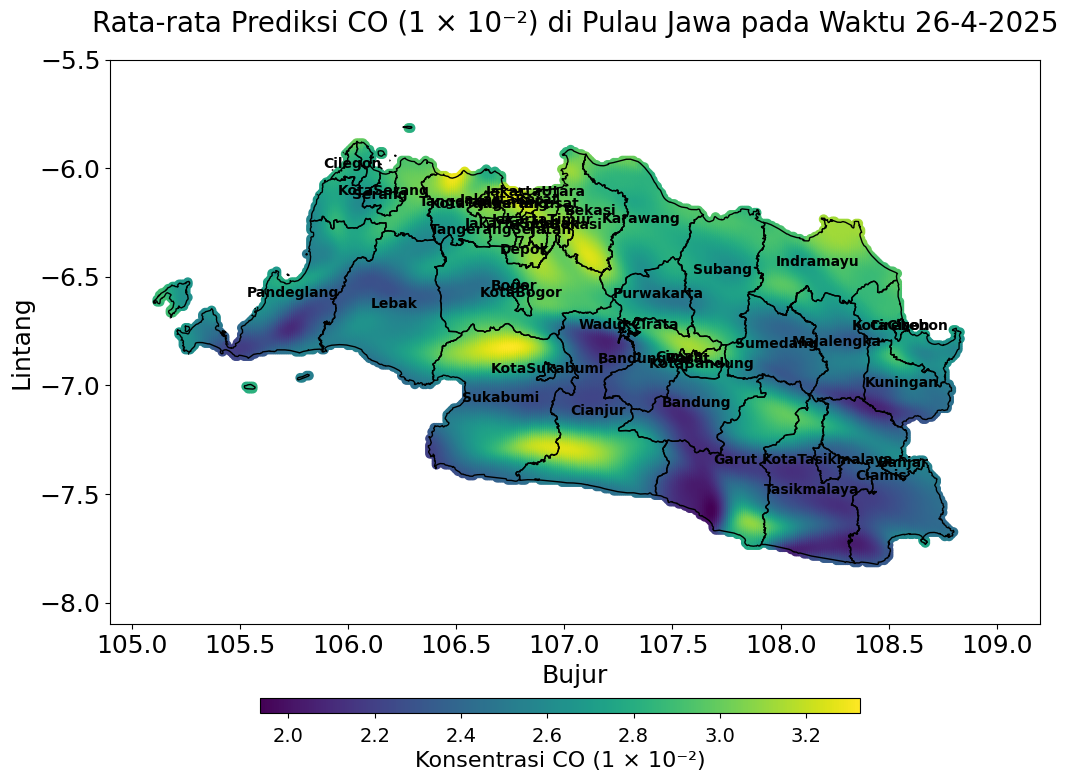

In [43]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd
import matplotlib as mpl
import matplotlib.patheffects as pe

# --- 2. Filter Data by Time ---
# Choose a specific time 't' to visualize
time_to_visualize = t  # Example: Visualize predictions at time step 365

filtered_prediction_df = prediction_df[prediction_df['t'] == time_to_visualize].copy()
if filtered_prediction_df.empty:
    print(f"No prediction data found for time = {time_to_visualize}.")
else:
    print(f"Filtered prediction data for time = {time_to_visualize}. Shape: {filtered_prediction_df.shape}")
    display(filtered_prediction_df.head())

    # --- 3. Prepare Geographical Data ---
    indonesia = gpd.read_file('https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_IDN_2.json')

    jawa_provinces = df.city.unique()
    jawa = indonesia[indonesia['NAME_2'].isin(jawa_provinces)]

    # --- 4. Merge Data ---
    geometry = [Point(xy) for xy in zip(filtered_prediction_df['x'], filtered_prediction_df['y'])]
    prediction_gdf = gpd.GeoDataFrame(filtered_prediction_df, geometry=geometry)

    merged_gdf = gpd.sjoin(prediction_gdf, jawa, how="inner", predicate="within")

    print("\nMerged GeoDataFrame:")
    display(merged_gdf.head())

    # --- 5. Visualize Predictions ---
    fig, ax = plt.subplots(figsize=(12,7.5))

    # Plot Java map
    jawa.plot(ax=ax, color='lightgray', edgecolor='black')

    # Plot predicted NO₂
    if not merged_gdf.empty:
        merged_gdf.plot(column='prediction', ax=ax, cmap='viridis')

    # --- Draw boundaries and add labels ---
    jawa.boundary.plot(ax=ax, color='black', linewidth=1)
    jawa['centroid'] = jawa.geometry.centroid

    for idx, row in jawa.iterrows():
        ax.annotate(
            text=row['NAME_2'],
            xy=(row['centroid'].x, row['centroid'].y),
            ha='center',
            fontsize=10,
            color='black',
            weight='bold'
        )

    # --- Colorbar ---
    cax = fig.add_axes([0.25, 0, 0.5, 0.02])  # [left, bottom, width, height]
    sm = plt.cm.ScalarMappable(
        cmap='viridis',
        norm=plt.Normalize(vmin=merged_gdf['prediction'].min(),
                           vmax=merged_gdf['prediction'].max())
    )
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
    cbar.set_label('Konsentrasi CO (1 × 10⁻²)', fontsize=16)
    cbar.ax.tick_params(labelsize=14,pad=6)

    # --- Titles and labels ---
    ax.set_title(
        f'Rata-rata Prediksi CO (1 × 10⁻²) di Pulau Jawa pada Waktu {target_day}-{target_month}-{target_year}',
        fontsize=20, pad=20
    )
    ax.set_xlabel('Bujur', fontsize=18)
    ax.set_ylabel('Lintang', fontsize=18)
    ax.tick_params(axis='both', labelsize=18)

    # --- Region limits ---
    ax.set_xlim(104.9, 109.2)
    ax.set_ylim(-8.1, -5.5)

    plt.show()


In [44]:
models_Adam_comb[3][0]

<PINN_NeuralNet name=pinn__neural_net, built=True>

In [45]:
unique_coords = filtered_df[["x_coord", "y_coord"]].round(6).drop_duplicates().reset_index(drop=True)
display(unique_coords)

,x_coord,y_coord
0,107.610720,-7.100013
1,107.414924,-6.897186
2,108.566579,-7.376339
3,107.120699,-6.215191
4,106.767609,-6.559987
...,...,...
363,107.980880,-6.825126
364,106.518714,-6.174249
365,106.707481,-6.301754
366,108.141338,-7.497079


In [46]:
t_points = np.arange(filtered_df["time"].min(), filtered_df["time"].max() + 1, 1)
xy_points = unique_coords

In [47]:
xy_points = unique_coords[['x_coord', 'y_coord']].to_numpy()

In [48]:
time_col = np.repeat(t_points, len(xy_points), axis=0)

# 2. Tile the entire block of xy pairs for the number of time points
coords_block = np.tile(xy_points, (len(t_points), 1))

# 3. Combine them into the final prediction grid
# We reshape time_col to (N, 1) to stack it horizontally with the (N, 2) coords_block
prediction_grid = np.concatenate([time_col[:, np.newaxis], coords_block], axis=1)

print("Time points:", len(t_points))
print("Unique XY pairs:", len(xy_points))
print("Prediction grid shape:", prediction_grid.shape)

Time points: 730
Unique XY pairs: 368
Prediction grid shape: (268640, 3)


In [49]:
prediction_df = models_Adam_comb[3][0].predict(prediction_grid)

8395/8395 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step


In [50]:
results_df = pd.DataFrame(prediction_grid, columns=['time', 'x_coord', 'y_coord'])
results_df['prediction'] = prediction_df
results_df

,time,x_coord,y_coord,prediction
0,0.0,107.610720,-7.100013,2.579169
1,0.0,107.414924,-6.897186,2.676290
2,0.0,108.566579,-7.376339,3.228035
3,0.0,107.120699,-6.215191,3.247515
4,0.0,106.767609,-6.559987,2.966675
...,...,...,...,...
268635,729.0,107.980880,-6.825126,2.444585
268636,729.0,106.518714,-6.174249,3.400511
268637,729.0,106.707481,-6.301754,3.194904
268638,729.0,108.141338,-7.497079,2.570783


In [51]:
# In your results DataFrame
results_df['x_rounded'] = results_df['x_coord'].round(6)
results_df['y_rounded'] = results_df['y_coord'].round(6)

# In your original filtered DataFrame
filtered_df['x_rounded'] = filtered_df['x_coord'].round(6)
filtered_df['y_rounded'] = filtered_df['y_coord'].round(6)

In [52]:
merged_df = pd.merge(
    results_df,
    filtered_df[['time', 'x_rounded', 'y_rounded', 'CO_filtered','city']], # Select only needed columns
    how='left',
    on=['time', 'x_rounded', 'y_rounded']
)
# merged_df = merged_df.drop(columns=['x_rounded', 'y_rounded'])

# Display the result
print(merged_df.head())
print(f"Original shape: {filtered_df.shape}")
print(f"Merged shape:   {merged_df.shape}")

   time     x_coord   y_coord  prediction   x_rounded  y_rounded  CO_filtered  \
0   0.0  107.610720 -7.100013    2.579169  107.610720  -7.100013     2.567886   
1   0.0  107.414924 -6.897186    2.676290  107.414924  -6.897186     2.664559   
2   0.0  108.566579 -7.376339    3.228035  108.566579  -7.376339     3.247597   
3   0.0  107.120699 -6.215191    3.247515  107.120699  -6.215191     3.200218   
4   0.0  106.767609 -6.559987    2.966675  106.767609  -6.559987     2.965752   

           city  
0       Bandung  
1  BandungBarat  
2        Banjar  
3        Bekasi  
4         Bogor  
Original shape: (138085, 9)
Merged shape:   (268640, 8)


In [53]:
city_lookup = filtered_df[['city', 'x_rounded', 'y_rounded']].copy()
city_lookup.drop_duplicates(subset=['x_rounded', 'y_rounded'], inplace=True)
city_lookup

,city,x_rounded,y_rounded
4828,Bandung,107.610720,-7.100013
4798,BandungBarat,107.414924,-6.897186
4799,Banjar,108.566579,-7.376339
4803,Bekasi,107.120699,-6.215191
4829,Bogor,106.767609,-6.559987
...,...,...,...
4811,Sumedang,107.980880,-6.825126
4827,Tangerang,106.518714,-6.174249
4832,TangerangSelatan,106.707481,-6.301754
4815,Tasikmalaya,108.141338,-7.497079


In [54]:
merged_city = pd.merge(
    merged_df,
    city_lookup[['x_rounded', 'y_rounded', 'city']].rename(columns={'city': 'city_lookup'}),
    on=['x_rounded', 'y_rounded'],
    how='left'
)

merged_city['city'] = merged_city['city'].fillna(merged_city['city_lookup'])
merged_city = merged_city.drop(columns=['city_lookup'])
merged_city

,time,x_coord,y_coord,prediction,x_rounded,y_rounded,CO_filtered,city
0,0.0,107.610720,-7.100013,2.579169,107.610720,-7.100013,2.567886,Bandung
1,0.0,107.414924,-6.897186,2.676290,107.414924,-6.897186,2.664559,BandungBarat
2,0.0,108.566579,-7.376339,3.228035,108.566579,-7.376339,3.247597,Banjar
3,0.0,107.120699,-6.215191,3.247515,107.120699,-6.215191,3.200218,Bekasi
4,0.0,106.767609,-6.559987,2.966675,106.767609,-6.559987,2.965752,Bogor
...,...,...,...,...,...,...,...,...
268635,729.0,107.980880,-6.825126,2.444585,107.980880,-6.825126,2.592858,Sumedang
268636,729.0,106.518714,-6.174249,3.400511,106.518714,-6.174249,3.408529,Tangerang
268637,729.0,106.707481,-6.301754,3.194904,106.707481,-6.301754,3.209184,TangerangSelatan
268638,729.0,108.141338,-7.497079,2.570783,108.141338,-7.497079,2.610040,Tasikmalaya


In [55]:
merged_city.drop(columns=['x_rounded', 'y_rounded'], inplace=True)

In [56]:
merged_city

,time,x_coord,y_coord,prediction,CO_filtered,city
0,0.0,107.610720,-7.100013,2.579169,2.567886,Bandung
1,0.0,107.414924,-6.897186,2.676290,2.664559,BandungBarat
2,0.0,108.566579,-7.376339,3.228035,3.247597,Banjar
3,0.0,107.120699,-6.215191,3.247515,3.200218,Bekasi
4,0.0,106.767609,-6.559987,2.966675,2.965752,Bogor
...,...,...,...,...,...,...
268635,729.0,107.980880,-6.825126,2.444585,2.592858,Sumedang
268636,729.0,106.518714,-6.174249,3.400511,3.408529,Tangerang
268637,729.0,106.707481,-6.301754,3.194904,3.209184,TangerangSelatan
268638,729.0,108.141338,-7.497079,2.570783,2.610040,Tasikmalaya


In [58]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Konversi 't' ke format tanggal
start_date = pd.to_datetime("2023-05-01")
merged_city['tanggal'] = merged_city['time'].apply(lambda x: start_date + pd.Timedelta(days=int(x)))

# Ensure numeric types
merged_city['prediction'] = pd.to_numeric(merged_city['prediction'], errors='coerce')
merged_city['CO_filtered'] = pd.to_numeric(merged_city['CO_filtered'], errors='coerce')

# Drop any rows with missing values in the relevant columns
clean_df = merged_city.dropna(subset=['prediction', 'CO_filtered', 'city']).copy()

# Group by city and compute MAE and MAPE
city_metrics = clean_df.groupby('city').apply(
    lambda g: pd.Series({
        'MAE': np.mean(np.abs(g['prediction'] - g['CO_filtered'])),
        'MAPE': np.mean(np.abs((g['prediction'] - g['CO_filtered']) / g['CO_filtered'])) * 100
    })
).reset_index()

# Display nicely
print(city_metrics.sort_values(by='MAPE',ascending=False))

                city       MAE      MAPE
22       KotaCirebon  0.064225  1.958151
9            Cirebon  0.062250  1.950835
4              Bogor  0.051935  1.687747
14      JakartaPusat  0.061307  1.645150
17      JakartaUtara  0.060243  1.621482
8             Cimahi  0.048823  1.582848
12         Indramayu  0.049640  1.544019
21         KotaBogor  0.051831  1.541331
19       KotaBandung  0.045863  1.518988
34            Subang  0.045678  1.496029
31        Purwakarta  0.047544  1.491519
32               Sea  0.046580  1.476054
33            Serang  0.047896  1.469942
1       BandungBarat  0.042811  1.466286
7            Cilegon  0.050617  1.463425
0            Bandung  0.037732  1.428551
15    JakartaSelatan  0.052492  1.428010
40       WadukCirata  0.046334  1.427349
30        Pandeglang  0.043213  1.390034
13      JakartaBarat  0.053008  1.385276
2             Banjar  0.042075  1.364836
28             Lebak  0.040401  1.352760
11             Garut  0.036072  1.329991
29        Majale

/tmp/ipython-input-3073695865.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  city_metrics = clean_df.groupby('city').apply(


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Konversi 't' ke format tanggal
start_date = pd.to_datetime("2023-05-01")
merged_city['tanggal'] = merged_city['time'].apply(lambda x: start_date + pd.Timedelta(days=int(x)))

# Daftar kota unik
cities = merged_city['city'].unique()

# Pengaturan font
plt.rcParams.update({'font.size': 14})

# Plot untuk setiap kota
for city in cities:
    df_city = merged_city[merged_city['city'] == city]

    plt.figure(figsize=(12, 4))
    plt.plot(df_city['tanggal'], df_city['prediction'], label='Prediksi CO', color='blue')
    plt.plot(df_city['tanggal'], df_city['CO_filtered'], label='CO Teramati (Hasil Pre-Processing)', color='orange')

    plt.title(f'Perbandingan Konsentrasi CO Teramati dan Hasil Prediksi PINN di {city}', fontsize=14)
    plt.xlabel('Tanggal', fontsize=14)
    plt.ylabel('Konsentrasi CO (10⁻² mol/m²)', fontsize=14)
    plt.legend(fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Output hidden; open in https://colab.research.google.com to view.